# 3장 세계은행 WITS API 추출

## 1. 개요 

WITS REST API를 사용하여 세계은행(World Bank)의 WITS 데이터베이스에 프로그래밍 방식으로 접근할 수 있다. 현재 **UNCTAD TRAINS** 데이터세트와 **Trade Stats**가 API 모듈을 통해 제공되고 있다. WITS API 모듈은 SDMX 방식과 URL 기반 구조 두 가지 요청 형식을 지원하며, 두 요청 방식의 데이터 응답 구조는 동일하며 현재 XML 형식으로 제공된다.

>**참고: SDMX 방식 vs. URL 기반 방식**
>
>SDMX 방식과 URL 기반 방식의 차이점은 데이터 요청과 전송 방식의 구조적 차이에서 비롯된다. 일반적으로 다음과 같은 차이가 있다. SDMX 방식은 SDMX(Statistical Data and Metadata Exchange) 표준을 따르는 XML 또는 JSON 기반의 구조화된 데이터 요청 방식을 사용한다. 데이터 요청이 계층적으로 구성되며, 다양한 데이터 소스와의 호환성이 높다. URL 기반 방식은 API 엔드포인트에 특정 URL 패턴을 사용하여 데이터를 요청하는 방식이다. RESTful API의 형식을 따르며, 일반적으로 직관적이고 간단한 구조를 갖는다.(**REST**는 Representational State Transfer의 약자로서 인터넷을 통해 데이터를 주고받는 방법을 표준화한 것임)

> **참고: [WITS(World Integrated Trade Solution)](https://wits.worldbank.org/Default.aspx?lang=en)**
>
> 세계은행은 UN무역개발회의(UNCTAD), 국제무역센터(ITC), 유엔 통계국(UNSD), 세계무역기구(WTO) 등의 기관과 협의하여 무역 및 관세 정보를 조회하고 검색할 수 있는 세계통합무역솔루션(WITS)을 개발했다. 다음과 같은 데이터베이스에 접근이 가능하다.
>
>**1. UN Comtrade**  
UN Comtrade(UNSD Commodity Trade) 데이터베이스는 상품 무역의 수출 및 수입 데이터를 품목별, 교역 상대국별로 제공한다. 이 데이터베이스는 170개 이상의 나라 정보를 포함하며, 1962년 이후 유엔에 보고된 통계를 제공한다. 모든 통계 및 데이터는 국제적으로 인정된 무역 및 관세 분류 체계에 따라 기록된다.
><br><br>
>**2. UNCTAD TRAINS**  
TRAINS(Trade Analysis Information System) 데이터베이스는 160개 이상의 나라에 대한 관세 및 비관세 조치 정보를 제공한다. 관세 및 비관세 조치 데이터는 가장 상세한 상품 코드 체계(HS, Harmonized System), 즉 나라별 관세품목(National Tariff Line) 수준에서 기록된다. 관세 정보에는 최혜국(MFN) 실행 관세율뿐만 아니라, 일반특혜관세(GSP), 지역무역협정(RTA), 기타 양자 간 특혜무역협정(PTA) 등의 관세율도 포함된다.
><br><br>
>**3. WTO IDB 및 CTS**  
WTO의 IDB(Integrated Data Base)는 품목별 및 교역 상대국별 수입 데이터를 제공하며, 적용 최혜국(MFN) 관세율 및 가능할 경우 특혜 관세율도 가장 상세한 품목 수준에서 제공한다. CTS(Consolidated Tariff Schedule Data Base)는 WTO 양허관세, 초기 협상권(Initial Negotiating Right), 기타 지표를 포함한다. CTS는 각국이 상품 협상(예: 우루과이라운드 다자간 무역협상)에서 양보한 사항을 반영한다. 
><br><br>
>**4. Global Preferential Trade Agreements Database**  
세계은행 및 다트머스대 터크 경영대학원 국제비즈니스센터의 글로벌특혜무역협정 데이터베이스는 세계 각국의 특혜무역협정(PTA) 정보를 제공한다. 특히, WTO에 아직 공식적으로 통보되지 않은 협정도 포함된다. 

## 2. TRAINS 데이터 API 추출

### 2.1 내용

UNCTAD TRAINS 데이터세트에는 특혜(`PREF`) 및 최혜국(`MFN`) 관세율이 들어 있다. 데이터는 HS의 6자리 수준에서 나라 간에 조정된다. 관세 데이터는 아래의 값을 지정하여 다운로드할 수 있다.

- **Reporter:** 보고자 ISO 나라 코드.
- **Partner:** (특혜) 관세율이 적용되는 나라 또는 나라 그룹.
- **Product Code:** 6자리 HS 코드. 
- **Year:** 관세가 유효했던 연도. 
- **Data Type:** 보고된 관세율만 있거나 또는 보고된 관세율과 UNCTAD 방법을 사용하여 추정된 AVE(Ad Valorem Equivalent; 종가세로 환산한) 관세율.

**데이터 요청 제한**

서버 과부하를 피하기 위한 제한 사항:

- 모든 제품의 관세율은 단일 보고자, 파트너 및 연도에 대해 요청할 수 있다.
- 단일의 보고자, 파트너, 제품에 대한 관세 일정은 여러 연도에 대해 요청할 수 있다.
- 하나 이상의 보고자, 하나 이상의 파트너, 하나 이상의 제품에 대한 관세율은 단일 연도에 대해 요청할 수 있다.
- `reported` 데이터 유형 또는 AVE estimated(`aveestimated`) 데이터 유형 중 하나를 단일 요청에서 요청할 수 있다.

**기본 호출 구조**

WITS API에 액세스하는 기본 URL: `https://wits.worldbank.org/API/V1`.

**URL 기반 구조 쿼리**

**Meta data**와 **data availability**에 액세스하는 기본 URL: `https://wits.worldbank.org/API/V1/WITS`. Data availability API는 UNCTAD TRAINS 관세 데이터세트에서 이용 가능한 나라/기간을 반환한다. 또한 이 API는 이용 가능한 파트너 코드와 특정 나라 기간에 대해 "종량세 관세 표현에 대한 추정 관세율"(estimated duty rate for specific duty expression)이 사용 가능한지 여부를 반환한다. 

**Tariff data** 요청의 기본 URL: `https://wits.worldbank.org/API/V1/SDMX/V21/`. 나라 및 파트너 이름을 얻으려면 **Reporter-Partner** API를 사용한다. 분류법 제목과 제품 설명을 얻으려면 각각 **nomenclature** API와 **Product** API를 사용한다. JSON 형식으로 관세 데이터를 얻으려면 데이터 요청 쿼리에 `?format=JSON`을 넣는다.

파라미터에 대해 둘 이상의 값에 액세스하려면 구분자 `;`를 사용하여 값을 구분한다.

**SDMX 쿼리**

- 기본 URL: `https://wits.worldbank.org/API/V1/SDMX/V21/rest/`.

**반환되는 항목**

| 항목 | 설명 |
|:----------|:----------|
| SimpleAverage | 해당 HS 6자리 코드 내 모든 나라 관세라인의 종가세율 단순 평균. OBS_Value는 응답에서 단순 평균. |
| TARIFFTYPE | 관세율이 특혜 관세(PREF)인지 최혜국 관세(MFN)인지 식별함. |
| TOTALNOOFLINES | 해당 HS 6자리 코드 내 모든 나라 관세라인의 총 수. |
| NBR_PREF_LINES | 특혜 관세가 적용되는 해당 HS 6자리 코드 내 국가 관세라인의 수. |
| NBR_MFN_LINES | 특혜 관세가 적용되지 않는 해당 HS 6자리 코드 내 국가 관세라인의 수 (단순 평균 계산에 MFN 요율이 사용됨). |
| NBR_NA_LINES | 종가세 형태가 아닌 특혜 관세가 적용되는 해당 HS 6자리 코드 내 국가 관세라인의 수 (단순 평균 계산에 포함되지 않음). |
| SUM_OF_RATES | 해당 HS 6자리 코드 내 모든 나라 관세라인의 종가세율 합계. |
| MIN_RATE | 해당 HS 6자리 코드 내 모든 나라 관세라인 중 가장 낮은 종가세율. |
| MAX_RATE | 해당 HS 6자리 코드 내 모든 나라 관세라인 중 가장 높은 종가세율. |
| NOMENCODE | 사용된 HS 개정판 (H0 = HS 1988/92, H1 = HS 1996, H2 = HS 2002, H3 = HS 2007, H4 = HS 2012). |
| EXCLUDEDFROM | 해당 제품에 대해 특혜 관세 적용에서 제외된 나라의 나라 코드. |

>**참고: 특혜 관세 vs. 최혜국 관세**
>
>특혜 관세(`PREF`)은 특정 나라들 간의 무역 협정에 따라 적용되는 낮은 관세율이다. 예를 들어, 자유무역협정(FTA)이나 관세 동맹에 참여하는 나라들끼리는 서로에게 낮은 관세를 부과한다. 최혜국 관세(`MFN`)는 세계무역기구(WTO) 회원국 간에 기본적으로 적용되는 관세율이다. 특혜무역협정에 포함되지 않은 경우, 이 관세율이 적용된다. MFN 관세율은 일반적으로 가장 높은(가장 제한적인) 관세율이다. 쉽게 말해, 특혜 관세는 특정 나라들끼리 서로 낮은 관세를 적용하는 것이고, 최혜국 관세는 모든 WTO 회원국 간에 기본적으로 적용되는 관세율이다.

### 2.2 URL 기반 구조 요청

#### ChatGPT 이용 API 호출 코드 작성법

이 장의 모든 API 요청 파이썬 코드는 ChatGPT를 활용하여 작성한 것이다. 첫 번째 "Reporter and Partner" 메타데이터를 얻는 코드를 예로 들어 ChatGPT 사용법을 설명하면 다음과 같다.

**STEP 1:** "Reporter and Partner" API 요청과 관련된 내용이 [WITS API USER GUIDE](https://wits.worldbank.org/data/public/WITSAPI_UserGuide.pdf) p.6)에 나와 있는데, 그 내용을 그대로 복사해서 ChatGPT에 다음과 같은 식으로 코드 작성을 요청한다.(아래 내용 중에는 필요한 핵심 요청사항 외에도 여러 정보들이 들어있는데 모두 다 집어 넣어도 ChatGPT가 알아서 잘 처리한다.)


>**다음 API를 호출하여 데이터프레임으로 변환하는 파이썬 코드를 알려줘.**
>
><br>
>
>Reporter and Partner:
>
>This API helps to obtain reporter and partner name, alpha numeric code, ISO3 code and other.
>
>Meta data about the countries that are available in the UNCTAD TRAINS dataset.
>
>URL: https://wits.worldbank.org/API/V1/wits/datasource/trn/country/ALL|:CountryCode|:CountryCodeList
>
>Method:  
>GET
>
>URL Parameter:  
>ALL: To retrieve all countries/partners Meta data.  
>:CountryCode= Three letter alpha numeric country code  
>:CountryCodeList= List of three letter alpha numeric country codes separated by delimiter(;)
>
>Response Format:  
>XML
>
>Success Response:  
>HTTP Response Status Code: 200
>
>Content: The response has the following information about the requested country/partner  
>• Country Code  
>• ISO3 Code  
>• Name  
>• Is the country code available as reporter?  
>• Is the country code available as partner?  
>• Is it a country code group?  
>• Group Type  
>• Notes  
>
>Sample Request:  
>To request all countries:  
>https://wits.worldbank.org/API/V1/wits/datasource/trn/country/ALL  
>To request a specific country:  
>https://wits.worldbank.org/API/V1/wits/datasource/trn/country/004  
>To request list of countries:  
>https://wits.worldbank.org/API/V1/wits/datasource/trn/country/004;840;G24


**STEP 2:** ChatGPT가 제공한 코드를 실행해보고, 만약 결과가 제대로 나오지 않는 경우에는 다음과 같이 response의 일부(예: 처음 2000자)를 출력하여 XML(또는 JSON) 구조를 ChatGPT에게 알려주고 코드를 수정시킨다. 즉, 아래의 출력 결과를 주면서 "응답의 처음 2000자를 확인한 결과다. 이를 이용해 코드를 수정해줘."라고 요구한다.

> print(response.text[:2000])  # 앞부분 2000자 출력


#### Reporter and Partner

[메타데이터] 이 API는 Reporter와 Partner 이름, 영어-숫자 코드, ISO3 코드 등을 제공한다.

In [1]:
import requests
import xml.etree.ElementTree as ET
import pandas as pd

# API 기본 URL
base_url = "https://wits.worldbank.org/API/V1/wits/datasource/trn/country/"

# 요청 파라미터 설정
country_codes = "ALL"
#country_codes = "410;840"

# API 요청 URL 생성
url = f"{base_url}/{country_codes}"

# API 요청
response = requests.get(url)
response.raise_for_status()  # 오류 발생 시 예외 처리

# XML 파싱
root = ET.fromstring(response.content)
namespace = "{http://wits.worldbank.org}"

# 데이터 추출
data = []
for country in root.findall(f".//{namespace}country"):
    data.append({
        "CountryCode": country.get("countrycode"),
        "ISO3Code": country.find(f"{namespace}iso3Code").text if country.find(f"{namespace}iso3Code") is not None else None,
        "Name": country.find(f"{namespace}name").text if country.find(f"{namespace}name") is not None else None,
        "IsReporter": country.get("isreporter"),
        "IsPartner": country.get("ispartner"),
        "IsGroup": country.get("isgroup"),
        "GroupType": country.get("grouptype"),
        "Notes": country.find(f"{namespace}notes").text if country.find(f"{namespace}notes") is not None else None
    })

# 데이터프레임 변환
df_selected_countries = pd.DataFrame(data)
df_selected_countries

,CountryCode,ISO3Code,Name,IsReporter,IsPartner,IsGroup,GroupType,Notes
0,A01,A01,Selected Developing Countries for Switzerland,0,1,Yes,Beneficiaries,None
1,A02,A02,Caribbean Economic Recovery Act: USA 2007,0,1,Yes,Beneficiaries,None
2,A03,A03,Caribbean Economic Recovery Act: USA 2009,0,1,Yes,Beneficiaries,None
3,A04,A04,Preferential tariff for selected african count...,0,1,Yes,Beneficiaries,None
4,A05,A05,Norway tariff for lower income GSP countries,0,1,Yes,Beneficiaries,None
...,...,...,...,...,...,...,...,...
476,890,YUG,"Yugoslavia,FR(Serbia/Montenegr",0,1,No,N/A,None
477,710,ZAF,South Africa,1,1,No,N/A,None
478,180,ZAR,"Congo, Dem. Rep.",1,1,No,N/A,None
479,894,ZMB,Zambia,1,1,No,N/A,None


| 코드 | 내용 |
|:----------|:----------|
| CountryCode | 나라 코드 |
| ISO3Code | ISO3 코드 |
| Name | 이름 |
| IsReporter | 나라 코드가 Reporter로 사용 가능한지 여부 |
| IsPartner | 나라 코드가 Partner로 사용 가능한지 여부 |
| IsGroup | 그룹 여부 |
| GroupType | 그룹 유형 |
| Notes | 비고 |

#### Nomenclature

[메타데이터] 이 API는 UNCTAD TRAINS 데이터세트에서 사용되는 제품 분류법(Nomenclature)에 대한 정보를 제공한다.

In [2]:
import requests
import xml.etree.ElementTree as ET
import pandas as pd

# API 기본 URL
base_url = "https://wits.worldbank.org/API/V1/wits/datasource/trn/nomenclature/"

# 요청 파라미터 설정
nomen_codes = "ALL"
#nomen_codes = "H0;H4"

# API 요청 URL 생성
url = f"{base_url}/{nomen_codes}"

# API 요청
response = requests.get(url)
response.raise_for_status()  # 오류 발생 시 예외 처리

# XML 파싱
root = ET.fromstring(response.content)
namespace = "{http://wits.worldbank.org}"

# 데이터 추출
data = []
for nomen in root.findall(f".//{namespace}nomenclature"):
    data.append({
        "NomenCode": nomen.get("nomenclaturecode"),
        "NomenDescription": nomen.get("description"),
        "NomenName": nomen.text if nomen.text is not None else None
    })

# 데이터프레임 변환
df_nomenclature = pd.DataFrame(data)
df_nomenclature

,NomenCode,NomenDescription,NomenName
0,H0,Harmonized System 1988/92,HS 1988/92
1,H1,Harmonized System 1996,HS 1996
2,H2,Harmonized System 2002,HS 2002
3,H3,Harmonized System 2007,HS 2007
4,H4,Harmonized System 2012,HS 2012
5,H5,Harmonized System 2017,HS 2017
6,H6,Harmonized System 2022,HS 2022


#### Product

[메타데이터] 이 API는 UNCTAD TRAINS 데이터세트에서 사용 가능한 Product에 대한 정보를 제공한다.

In [3]:
import requests
import xml.etree.ElementTree as ET
import pandas as pd

# API 기본 URL
base_url = "https://wits.worldbank.org/API/V1/wits/datasource/trn/product/"

# 요청 파라미터 설정
product_codes = "all"

# API 요청 URL 생성
url = f"{base_url}/{product_codes}"

# API 요청
response = requests.get(url)
response.raise_for_status()  # 오류 발생 시 예외 처리

# XML 파싱
root = ET.fromstring(response.content)
namespace = "{http://wits.worldbank.org}"

# 데이터 추출
data = []
for product in root.findall(f".//{namespace}product"):
    data.append({
        "ProductCode": product.get("productcode"),
        "ProductDescription": product.get("description"),
        "IsGroup": product.get("isgroup"),
        "GroupType": product.get("grouptype"),
        "Notes": product.find(f"{namespace}notes").text if product.find(f"{namespace}notes") is not None else None
    })

# 데이터프레임 변환
df_product = pd.DataFrame(data)
df_product

,ProductCode,ProductDescription,IsGroup,GroupType,Notes
0,010110,None,No,N/A,None
1,010111,None,No,N/A,None
2,010119,None,No,N/A,None
3,010120,None,No,N/A,None
4,010121,None,No,N/A,None
...,...,...,...,...,...
6877,970531,None,No,N/A,None
6878,970539,None,No,N/A,None
6879,970600,None,No,N/A,None
6880,970610,None,No,N/A,None


**NOTE!!**

위 출력 결과를 보면 `ProductDescription`이 제대로 추출되지 않았다. 다음과 같이 response의 앞부분 2000자를 출력하여 XML 구조를 ChatGPT에게 (출력된 내용을 그대로) 알려주고 코드 수정을 요구한다.

In [4]:
print(response.text[:2000]) # 앞부분 2000자 출력

ï»¿<?xml version="1.0" encoding="utf-8"?>
<wits:datasource datasourcecode="TRN" datasourcename="WITS - UNTCTAD TRAINS" language="en" total="6882" xmlns:wits="http://wits.worldbank.org">
  <wits:products>
    <wits:product productcode="010110" isgroup="No" nomenclaturecode="HS" grouptype="N/A">
      <wits:productdescription>010110 -- (2002-2011) - Pure-bred breeding animals</wits:productdescription>
      <wits:notes />
    </wits:product>
    <wits:product productcode="010111" isgroup="No" nomenclaturecode="HS" grouptype="N/A">
      <wits:productdescription>010111 -- (-2001) -- Pure-bred breeding animals</wits:productdescription>
      <wits:notes />
    </wits:product>
    <wits:product productcode="010119" isgroup="No" nomenclaturecode="HS" grouptype="N/A">
      <wits:productdescription>010119 -- (-2001) -- Other</wits:productdescription>
      <wits:notes />
    </wits:product>
    <wits:product productcode="010120" isgroup="No" nomenclaturecode="HS" grouptype="N/A">
      <wits:

**수정된 결과**

In [5]:
import requests
import xml.etree.ElementTree as ET
import pandas as pd

# API 기본 URL
base_url = "https://wits.worldbank.org/API/V1/wits/datasource/trn/product/"

# 요청 파라미터 설정
product_codes = "all"

# API 요청 URL 생성
url = f"{base_url}{product_codes}"

# API 요청
response = requests.get(url)
response.raise_for_status()  # 오류 발생 시 예외 처리

# XML 파싱
root = ET.fromstring(response.content)
namespace = {"wits": "http://wits.worldbank.org"}

# 데이터 추출
data = []
for product in root.findall(".//wits:product", namespace):
    product_description = product.find("wits:productdescription", namespace)
    notes = product.find("wits:notes", namespace)

    data.append({
        "ProductCode": product.get("productcode"),
        "ProductDescription": product_description.text if product_description is not None else None,
        "IsGroup": product.get("isgroup"),
        "NomenclatureCode": product.get("nomenclaturecode"),
        "GroupType": product.get("grouptype"),
        "Notes": notes.text if notes is not None else None
    })

# 데이터프레임 변환
df_product = pd.DataFrame(data)
df_product

,ProductCode,ProductDescription,IsGroup,NomenclatureCode,GroupType,Notes
0,010110,010110 -- (2002-2011) - Pure-bred breeding ani...,No,HS,N/A,None
1,010111,010111 -- (-2001) -- Pure-bred breeding animals,No,HS,N/A,None
2,010119,010119 -- (-2001) -- Other,No,HS,N/A,None
3,010120,"010120 -- (-2001) - Asses, mules and hinnies",No,HS,N/A,None
4,010121,010121 -- (2012-) -- Pure-bred breeding animals,No,HS,N/A,None
...,...,...,...,...,...,...
6877,970531,970531 -- (2022) -- Collections and collectors...,No,HS,N/A,None
6878,970539,970539 -- (2022) -- Collections and collectors...,No,HS,N/A,None
6879,970600,970600 -- Antiques of an age exceeding 100 years,No,HS,N/A,None
6880,970610,970610 -- (2022) -- Antiques; of an age exceed...,No,HS,N/A,None


#### Data Availability

[메타데이터] 이 API는 전체 TRAINS 데이터세트의 데이터 Availability(가용성) 또는 하나 이상의 Reporter에 대한 데이터 가용성 또는 주어진 연도의 tariff available countries information을 제공한다.

In [6]:
import requests
import xml.etree.ElementTree as ET
import pandas as pd

# API 기본 URL
base_url = "https://wits.worldbank.org/API/V1/wits/datasource/trn/dataavailability/"

# 요청 파라미터 설정

#country_codes = "all"
#years = "all"
country_codes = "410"
years = "all"

# API 요청 URL 생성
url = f"{base_url}/country/{country_codes}/year/{years}"

# API 요청
response = requests.get(url)
response.raise_for_status()  # 오류 발생 시 예외 처리

# XML 파싱
root = ET.fromstring(response.content)
namespace = "{http://wits.worldbank.org}"

# 데이터 추출
data = []
for reporter in root.findall(f".//{namespace}reporter"):
    data.append({
        "CountryCode": reporter.get("countrycode"),
        "ISO3Code": reporter.get("iso3Code"),
        "IsGroup": reporter.get("isgroup"),
        "GroupType": reporter.get("grouptype"),
        "CountryName": reporter.find(f"{namespace}name").text if reporter.find(f"{namespace}name") is not None else None,
        "Year": reporter.find(f"{namespace}year").text if reporter.find(f"{namespace}year") is not None else None,
        "ReportedNomenclature": reporter.find(f"{namespace}reporternernomenclature").text if reporter.find(f"{namespace}reporternernomenclature") is not None else None,
        "PreferentialAgreements": reporter.find(f"{namespace}numberofpreferentialagreement").text if reporter.find(f"{namespace}numberofpreferentialagreement") is not None else None,
        "PartnerList": reporter.find(f"{namespace}partnerlist").text if reporter.find(f"{namespace}partnerlist") is not None else None,
        "EstimatedTariffAvailable": reporter.find(f"{namespace}isspecificdutyexpressionestimatedavailable").text if reporter.find(f"{namespace}isspecificdutyexpressionestimatedavailable") is not None else None,
        "Notes": reporter.find(f"{namespace}notes").text if reporter.find(f"{namespace}notes") is not None else None,
        "LastUpdated": reporter.find(f"{namespace}lastupdateddate").text if reporter.find(f"{namespace}lastupdateddate") is not None else None
    })

# 데이터프레임 변환
df_data_availability = pd.DataFrame(data)
df_data_availability

,CountryCode,ISO3Code,IsGroup,GroupType,CountryName,Year,ReportedNomenclature,PreferentialAgreements,PartnerList,EstimatedTariffAvailable,Notes,LastUpdated
0,410,KOR,No,N/A,"Korea, Rep.",1988,Harmonized System 1988/92,6,000;050;418;N01;N45;,Yes,None,2014/08/04
1,410,KOR,No,N/A,"Korea, Rep.",1989,Harmonized System 1988/92,3,000;418;,Yes,None,2014/08/04
2,410,KOR,No,N/A,"Korea, Rep.",1990,Harmonized System 1988/92,1,000;,Yes,None,2014/08/04
3,410,KOR,No,N/A,"Korea, Rep.",1992,Harmonized System 1988/92,1,000;,Yes,None,2014/08/04
4,410,KOR,No,N/A,"Korea, Rep.",1995,Harmonized System 1988/92,1,000;,No,None,2014/08/04
5,410,KOR,No,N/A,"Korea, Rep.",1996,Harmonized System 1996,1,000;,Yes,None,2014/08/04
6,410,KOR,No,N/A,"Korea, Rep.",1997,Harmonized System 1996,1,000;,Yes,None,2015/03/03
7,410,KOR,No,N/A,"Korea, Rep.",1998,Harmonized System 1996,1,000;,Yes,None,2015/03/03
8,410,KOR,No,N/A,"Korea, Rep.",1999,Harmonized System 1996,0,000;,Yes,None,2014/08/04
9,410,KOR,No,N/A,"Korea, Rep.",2000,Harmonized System 1996,1,000;,Yes,None,2015/03/03


#### Tariff Data

이 API는 교역 및 비교역 관세품목 데이터를 조회하는 기능을 제공한다. 다양한 옵션을 통해 관세율 정보를 검색할 수 있으며, 나라-기간-교역상대국의 전체 관세율 또는 나라-교역상대국-제품별 관세율을 기간별로 요청할 수 있다.

| 파라미터 | 설명 |
|:--------|:-----|
| Data Source | UNCTAD TRAINS 데이터세트의 값은 "TRN". |
| Data Type | "reported" 또는 "aveestimated". |
| Reporter | "All" 또는 Reporter 코드(앞의 메타데이터 참조) 리스트. |
| Product | "All" 또는 Product 코드(앞의 메타데이터 참조) 리스트. |
| Partner | "All" 또는 Partner 코드(앞의 메타데이터 참조) 리스트. |
| Year | "All" 또는 연도(앞의 메타데이터 참조) 리스트. |
| Format | "JSON". JSON 형식으로 반환. |

In [7]:
import requests
import xml.etree.ElementTree as ET
import pandas as pd

# API 기본 URL
base_url = "https://wits.worldbank.org/API/V1/SDMX/V21/datasource/TRN/"

# 요청 파라미터 설정(미국-전세계-HS020110제품-2000년)
reporter = "840"
partner = "000"
product = "020110"
year = "2000"
datatype = "reported"

# 요청 파라미터 설정(한국-전세계-전제품-2000년)
reporter = "410"
partner = "000"
product = "all"
year = "2000"
datatype = "reported"
    
# API 요청 URL 생성
url = (
    f"{base_url}/"
    f"reporter/{reporter}/"
    f"partner/{partner}/"
    f"product/{product}/"
    f"year/{year}/"
    f"datatype/{datatype}"
)

# API 요청
response = requests.get(url)
response.raise_for_status()  # 오류 발생 시 예외 처리

# XML 파싱
root = ET.fromstring(response.content)

# 데이터 추출
data_list = []
for series in root.findall(".//Series"):
    series_data = series.attrib  # Series 속성 (FREQ, REPORTER, PARTNER, PRODUCTCODE, INDICATOR)

    for obs in series.findall(".//Obs"):
        obs_data = obs.attrib  # TIME_PERIOD, OBS_VALUE, TARIFFTYPE 등의 값

        combined_data = {
            "FREQ": series_data.get("FREQ"),
            "DATATYPE": series_data.get("DATATYPE"),
            "PRODUCTCODE": series_data.get("PRODUCTCODE"),
            "PARTNER": series_data.get("PARTNER"),
            "REPORTER": series_data.get("REPORTER"),
            "Time": obs_data.get("TIME_PERIOD"),
            "Value": obs_data.get("OBS_VALUE"),
            "TARIFFTYPE": obs_data.get("TARIFFTYPE"),
            "OBS_VALUE_MEASURE": obs_data.get("OBS_VALUE_MEASURE"),
            "TOTALNOOFLINES": obs_data.get("TOTALNOOFLINES"),
            "NBR_PREF_LINES": obs_data.get("NBR_PREF_LINES"),
            "NBR_MFN_LINES": obs_data.get("NBR_MFN_LINES"),
            "NBR_NA_LINES": obs_data.get("NBR_NA_LINES"),
            "SUM_OF_RATES": obs_data.get("SUM_OF_RATES"),
            "MIN_RATE": obs_data.get("MIN_RATE"),
            "MAX_RATE": obs_data.get("MAX_RATE"),
            "NOMENCODE": obs_data.get("NOMENCODE")
        }
        data_list.append(combined_data)

# 데이터프레임 변환
df_tariff_data = pd.DataFrame(data_list)
df_tariff_data

,FREQ,DATATYPE,PRODUCTCODE,PARTNER,REPORTER,Time,Value,TARIFFTYPE,OBS_VALUE_MEASURE,TOTALNOOFLINES,NBR_PREF_LINES,NBR_MFN_LINES,NBR_NA_LINES,SUM_OF_RATES,MIN_RATE,MAX_RATE,NOMENCODE
0,A,Reported,010111,000,410,2000,8,MFN,SimpleAverage,1,0,1,0,8,8,8,H1
1,A,Reported,010119,000,410,2000,8,MFN,SimpleAverage,2,0,2,0,16,8,8,H1
2,A,Reported,010120,000,410,2000,8,MFN,SimpleAverage,1,0,1,0,8,8,8,H1
3,A,Reported,010210,000,410,2000,93.0999984741211,MFN,SimpleAverage,3,0,3,0,279.299987792969,93.0999984741211,93.0999984741211,H1
4,A,Reported,010290,000,410,2000,27.8666667938232,MFN,SimpleAverage,3,0,3,0,83.5999984741211,0,41.7999992370605,H1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5108,A,Reported,970200,000,410,2000,0,MFN,SimpleAverage,1,0,1,0,0,0,0,H1
5109,A,Reported,970300,000,410,2000,0,MFN,SimpleAverage,2,0,2,0,0,0,0,H1
5110,A,Reported,970400,000,410,2000,0,MFN,SimpleAverage,2,0,2,0,0,0,0,H1
5111,A,Reported,970500,000,410,2000,0,MFN,SimpleAverage,1,0,1,0,0,0,0,H1


**참고: HS 020110 제품명 알아내기**

- Product 메타데이터 API 호출 결과 이용

In [8]:
import requests
import xml.etree.ElementTree as ET
import pandas as pd

# API 기본 URL
base_url = "https://wits.worldbank.org/API/V1/wits/datasource/trn/product/"

# 요청 파라미터 설정
product_codes = "020110"

# API 요청 URL 생성
url = f"{base_url}{product_codes}"

# API 요청
response = requests.get(url)
response.raise_for_status()  # 오류 발생 시 예외 처리

# XML 파싱
root = ET.fromstring(response.content)
namespace = {"wits": "http://wits.worldbank.org"}

# 데이터 추출
data = []
for product in root.findall(".//wits:product", namespace):
    product_description = product.find("wits:productdescription", namespace)
    notes = product.find("wits:notes", namespace)

    data.append({
        "ProductCode": product.get("productcode"),
        "ProductDescription": product_description.text if product_description is not None else None,
        "IsGroup": product.get("isgroup"),
        "NomenclatureCode": product.get("nomenclaturecode"),
        "GroupType": product.get("grouptype"),
        "Notes": notes.text if notes is not None else None
    })

# 데이터프레임 변환
df_product = pd.DataFrame(data)
df_product

,ProductCode,ProductDescription,IsGroup,NomenclatureCode,GroupType,Notes
0,020110,020110 -- - Carcases and half-carcases,No,HS,N/A,None


### 2.3 SDMX 쿼리 요청

SDMX 쿼리 요청 유형에는 두 가지가 있다. 하나는 메타데이터를 가져오는 요청 유형이고, 다른 하나는 관세 데이터를 가져오는 요청 유형이다. 다음 두 가지 SDMX 응답 형식이 지원된다.

- **SDMX-ML 2.1 generic schema:** 기본적으로 이 방식의 응답이 제공된다.
- **SDMX-ML 2.1 structure specific schema:** 구조 특정 스키마는 대량의 데이터를 처리하는 데 더 적합하다. 이 형식으로 응답을 받으려면 SDMX 쿼리 요청의 HTTP 요청 헤더 필드를 "Accept: application/vnd.sdmx.structurespecificdata+xml"로 수정한다. 
- **JSON 형식:** JSON 형식으로 데이터를 받으려면 SDMX 데이터 쿼리 요청의 HTTP 요청 헤더 필드를 "Accept: application/vnd.sdmx.data+json;version=1.0.0-wd"로 수정한다.

#### Data Flow

이 API는 UNCTAD TRAINS 데이터세트의 고유 데이터세트 코드를 제공한다.

In [9]:
import requests
import xml.etree.ElementTree as ET
import pandas as pd

# API 요청
url = "https://wits.worldbank.org/API/V1/SDMX/V21/rest/dataflow/wbg_wits/"
response = requests.get(url)
response.raise_for_status()  # 오류 발생 시 예외 처리

# XML 파싱
root = ET.fromstring(response.content)
namespace = "{http://www.sdmx.org/resources/sdmxml/schemas/v2_1/structure}"
common_namespace = "{http://www.sdmx.org/resources/sdmxml/schemas/v2_1/common}"

# 데이터 추출
data = []
for dataflow in root.findall(f".//{namespace}Dataflow"):
    data.append({
        "DataFlowID": dataflow.get("id"),
        "AgencyID": dataflow.get("agencyID"),
        "Version": dataflow.get("version"),
        "IsFinal": dataflow.get("isFinal"),
        "Name": dataflow.find(f"{common_namespace}Name").text if dataflow.find(f"{common_namespace}Name") is not None else None,
        "Description": dataflow.find(f"{common_namespace}Description").text if dataflow.find(f"{common_namespace}Description") is not None else None
    })

# 데이터프레임 변환
df_dataflow = pd.DataFrame(data)
df_dataflow

,DataFlowID,AgencyID,Version,IsFinal,Name,Description
0,DF_WITS_Tariff_TRAINS,WBG_WITS,1.1,false,WITS - UNCTAD TRAINS Tariff Data,Data flow to access WITS - UNCTAD TRAINS Prefe...
1,DF_WITS_TradeStats_Development,WBG_WITS,1.0,false,WITS TradeStats Devlopment,"Development indicators such as GDP, GNI per ca..."
2,DF_WITS_TradeStats_Tariff,WBG_WITS,1.0,false,WITS TradeStats Tariff,Tariff information like number of trade agreem...
3,DF_WITS_TradeStats_Trade,WBG_WITS,1.0,false,WITS TradeStats Trade,"Trade data such as total exports, number or pr..."


#### Code List

이 API는 WITS API의 전체 데이터세트에 대한 코드 리스트를 제공한다.

In [10]:
import requests
import xml.etree.ElementTree as ET
import pandas as pd

# API 요청
url = "https://wits.worldbank.org/API/V1/SDMX/V21/rest/codelist/all"
response = requests.get(url)
response.raise_for_status()  # 오류 발생 시 예외 처리

# XML 파싱
root = ET.fromstring(response.content)
namespace = "{http://www.sdmx.org/resources/sdmxml/schemas/v2_1/structure}"
common_namespace = "{http://www.sdmx.org/resources/sdmxml/schemas/v2_1/common}"

# 데이터 추출
data = []
for codelist in root.findall(f".//{namespace}Codelist"):
    for code in codelist.findall(f"{namespace}Code"):
        data.append({
            "CodeListID": codelist.get("id"),
            "AgencyID": codelist.get("agencyID"),
            "Version": codelist.get("version"),
            "Code": code.get("id"),
            "Name": code.find(f"{common_namespace}Name").text if code.find(f"{common_namespace}Name") is not None else None
        })

# 데이터프레임 변환
df_codelist = pd.DataFrame(data)
df_codelist

,CodeListID,AgencyID,Version,Code,Name
0,CL_UPDATE_STATUS,MA,1.0,Added,Added
1,CL_UPDATE_STATUS,MA,1.0,Updated,Updated
2,CL_UPDATE_STATUS,MA,1.0,Deleted,Deleted
3,SDMX_M_PERIODS,MA,1.0,01,01
4,SDMX_M_PERIODS,MA,1.0,02,02
...,...,...,...,...,...
7212,CL_TS_PRODUCTCODE_WITS,WBG_WITS,1.0,Transp,Machinery and Transport Equipment
7213,CL_TS_PRODUCTCODE_WITS,WBG_WITS,1.0,UNCTAD-SoP1,Raw materials
7214,CL_TS_PRODUCTCODE_WITS,WBG_WITS,1.0,UNCTAD-SoP2,Intermediate goods
7215,CL_TS_PRODUCTCODE_WITS,WBG_WITS,1.0,UNCTAD-SoP3,Consumer goods


#### Data Structure Definition (DSD)

이 API는 UNCTAD TRAINS 데이터세트의 데이터 구조 정의(DSD)를 제공한다.

In [11]:
import requests
import xml.etree.ElementTree as ET
import pandas as pd

# API 요청
url = "https://wits.worldbank.org/API/V1/SDMX/V21/rest/datastructure/WBG_WITS/TARIFF_TRAINS/"
response = requests.get(url)
response.raise_for_status()  # 오류 발생 시 예외 처리

# XML 파싱
root = ET.fromstring(response.content)
namespace = "{http://www.sdmx.org/resources/sdmxml/schemas/v2_1/structure}"
common_namespace = "{http://www.sdmx.org/resources/sdmxml/schemas/v2_1/common}"

# 데이터 추출
data = []
for datastructure in root.findall(f".//{namespace}DataStructure"):
    for component in datastructure.findall(f".//{namespace}Dimension"):
        data.append({
            "StructureID": datastructure.get("id"),
            "AgencyID": datastructure.get("agencyID"),
            "Version": datastructure.get("version"),
            "ComponentID": component.get("id"),
            "Name": component.find(f"{common_namespace}Name").text if component.find(f"{common_namespace}Name") is not None else None
        })

# 데이터프레임 변환
df_dsd = pd.DataFrame(data)
df_dsd

,StructureID,AgencyID,Version,ComponentID,Name
0,TARIFF_TRAINS,WBG_WITS,1.1,FREQ,None
1,TARIFF_TRAINS,WBG_WITS,1.1,REPORTER,None
2,TARIFF_TRAINS,WBG_WITS,1.1,PARTNER,None
3,TARIFF_TRAINS,WBG_WITS,1.1,PRODUCTCODE,None
4,TARIFF_TRAINS,WBG_WITS,1.1,DATATYPE,None


#### Tariff Data

이 API는 교역 및 비교역 관세품목의 관세 데이터를 조회한다. 다양한 옵션을 제공하여 관세율을 검색할 수 있으며, 나라-기간-교역상대국 전체 관세율 또는 나라-교역상대국-제품별 관세율을 특정 기간에 대해 요청할 수 있다.

| 파라미터 | 설명 |
|:---------|:-----|
| Freq | 주기의 가능한 값은 "A"이다. |
| DataType | "reported" 또는 "aveestimated" 값을 가질 수 있다. |
| Reporter | 코드 리스트에서 단일 나라 코드 또는 나라 코드 리스트 값을 가질 수 있다. 값이 지정되지 않으면 모든 이용 가능한 reporter로 간주된다. |
| Product | 단일 product 코드 또는 product 코드 리스트 값을 가질 수 있다. 값이 지정되지 않으면 모든 이용 가능한 product 코드로 간주된다. |
| Partner | 단일 partner 코드 또는 partner 코드 리스트 값을 가질 수 있다. |
| StartPeriod | 1988년 이후의 값을 가질 수 있다. 값이 지정되지 않으면 이용 가능한 연도의 관세 데이터가 반환된다. |
| EndPeriod | 1988년 이후의 값을 가질 수 있다. 값이 지정되지 않으면 시작 기간부터 최신 이용 가능한 연도까지의 관세 데이터가 반환된다. |
| Detail | 선택적 파라미터로, 반환될 정보의 양을 지정한다. 아래 값 중 하나를 가질 수 있다. <br> - Full: 모든 데이터 및 문서, 주석 포함 (기본값) <br> - DataOnly: 속성 및 그룹이 제외된다. <br> - SeriesKeysOnly: 시리즈 키를 구성하는 시리즈 요소 및 차원만 포함된다. <br> - NoData: 속성 및 주석을 포함한 그룹 및 시리즈를 반환하지만 관측값은 제외된다. |

In [12]:
import requests
import xml.etree.ElementTree as ET
import pandas as pd

# API 기본 URL
base_url = "https://wits.worldbank.org/API/V1/SDMX/V21/rest/data/DF_WITS_Tariff_TRAINS/"

# 요청 파라미터 설정(미국-전세계-HS020110제품-2000년)
params = {
    "freq": "A",
    "reporter": "840",
    "partner": "000",
    "product": "020110",
    "datatype": "reported",
    "start_year": "2000",
    "end_year": "2000",
    "detail": "Full"
}

# 요청 파라미터 설정(한국-전세계-전제품-2000년)
params = {
    "freq": "A",
    "reporter": "410",
    "partner": "000",
    "product": "",
    "datatype": "reported",
    "start_year": "2000",
    "end_year": "2000",
    "detail": "Full"
}

# API 요청 URL 생성
url = (
    f"{base_url}"
    f"{params['freq']}."
    f"{params['reporter']}."
    f"{params['partner']}."
    f"{params['product']}."
    f"{params['datatype']}"
    f"/?startperiod={params['start_year']}"
    f"&endperiod={params['end_year']}"
    f"&detail={params['detail']}"
)
    
# API 요청
response = requests.get(url)
response.raise_for_status()  # 오류 발생 시 예외 처리

# XML 파싱
root = ET.fromstring(response.content)
namespace = "{http://www.sdmx.org/resources/sdmxml/schemas/v2_1/data/generic}"

# 데이터 추출
data = []
for series in root.findall(f".//{namespace}Series"):
    series_key = {dim.get("id"): dim.get("value") for dim in series.findall(f".//{namespace}SeriesKey/{namespace}Value")}
    for obs in series.findall(f".//{namespace}Obs"):
        obs_time = obs.find(f"{namespace}ObsDimension").get("value")
        obs_value = obs.find(f"{namespace}ObsValue").get("value")
        attributes = {attr.get("id"): attr.get("value") for attr in obs.findall(f".//{namespace}Attributes/{namespace}Value")}
        data.append({**series_key, "Time": obs_time, "Value": obs_value, **attributes})

# 데이터프레임 변환
df_tariff = pd.DataFrame(data)
df_tariff

,FREQ,DATATYPE,PRODUCTCODE,PARTNER,REPORTER,Time,Value,TARIFFTYPE,OBS_VALUE_MEASURE,TOTALNOOFLINES,NBR_PREF_LINES,NBR_MFN_LINES,NBR_NA_LINES,SUM_OF_RATES,MIN_RATE,MAX_RATE,NOMENCODE
0,A,Reported,010111,000,410,2000,8,MFN,SimpleAverage,1,0,1,0,8,8,8,H1
1,A,Reported,010119,000,410,2000,8,MFN,SimpleAverage,2,0,2,0,16,8,8,H1
2,A,Reported,010120,000,410,2000,8,MFN,SimpleAverage,1,0,1,0,8,8,8,H1
3,A,Reported,010210,000,410,2000,93.0999984741211,MFN,SimpleAverage,3,0,3,0,279.299987792969,93.0999984741211,93.0999984741211,H1
4,A,Reported,010290,000,410,2000,27.8666667938232,MFN,SimpleAverage,3,0,3,0,83.5999984741211,0,41.7999992370605,H1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5108,A,Reported,970200,000,410,2000,0,MFN,SimpleAverage,1,0,1,0,0,0,0,H1
5109,A,Reported,970300,000,410,2000,0,MFN,SimpleAverage,2,0,2,0,0,0,0,H1
5110,A,Reported,970400,000,410,2000,0,MFN,SimpleAverage,2,0,2,0,0,0,0,H1
5111,A,Reported,970500,000,410,2000,0,MFN,SimpleAverage,1,0,1,0,0,0,0,H1


## 3. TRADE Stats 데이터 API 추출

### 3.1 내용

TRADE Stats는 집계된 무역 및 관세 데이터, 무역 관련 경제개발 지표를 제공한다.

**Trade Stats – Trade:** 총 수출액, 수출된 제품 수, 수출 및 수입 상대국, 수출 및 수입된 제품 그룹 등의 무역 데이터를 제공한다. Hirschman-Herfindahl 시장집중도 지수, 시장 침투(penetration) 지수, 세계 성장률 및 나라 성장률과 같은 무역 지표도 포함된다.

**Trade Stats – Tariff:** 무역 협정 수, 단순 및 가중 평균 관세, 면세 수입액, 면세 상품 비율과 같은 관세 정보가 제공된다.

**Trade Stats – Development:** GDP, 1인당 GNI, 무역수지, GDP 대비 무역 및 서비스 무역 비율과 같은 경제개발 지표가 제공된다.

무역, 관세, 경제개발 지표 데이터는 다음의 값을 지정하여 다운로드할 수 있다.

- **Reporter:** Reporter ISO3 코드. 
- **Partner:** Partner ISO3 코드. 파트너 차원이 적용되지 않는 지표의 경우 "999"를 사용.
- **Product 코드:** Sector, Stage of Processing, SITC Rev2 Standard 그룹에 속하는 제품 그룹 코드를 사용할 수 있다. 제품 차원이 적용되지 않는 지표의 경우 "999999"를 사용.
- **연도:** 연도. 시작 연도는 1988년.
- **지표:** 무역, 관세, 경제개발 지표 코드. 

**데이터 요청 제한**

서버 과부하를 피하기 위한 제한 사항:

- "All" 값은 최대 2개의 차원만 허용된다.
- 모든 Reporter와 모든 Partner를 포함한 데이터 요청은 허용되지 않는다.
- 두 개의 차원이 "All" 값을 가질 때 나머지 차원은 특정 값을 가져야 한다.
- 단일의 Reporter, Partner, 지표, 제품에 대한 무역 통계 데이터는 여러 연도에 대해 요청할 수 있다.

**기본 호출 구조**

WITS API에 액세스하는 기본 URL은 `https://wits.worldbank.org/API/V1`. 

**URL 기반 구조 쿼리**

메타데이터 및 data availability에 액세스하려면 기본 URL은 `https://wits.worldbank.org/API/V1/WITS`. **Data availability API**는 Trade Stats –
Trade/Tariff/Development 데이터세트에서 이용 가능한 나라 기간을 반환한다. **Indicator API**는 지표에 대해 파트너, 제품 차원이 필요한지 여부를 반환한다. Reporter-Partner API는 Reporter와 Partner의 이름을 제공한다. Nomenclature API와 Product API는 각각 제품 분류법과 제품 설명을 제공한다. 

데이터 요청의 기본 URL은 `https://wits.worldbank.org/API/V1/SDMX/V21/`. 파라미터에 대해 둘 이상의 값을 액세스하려면 구분자 `;`를 사용한다. JSON 형식으로 데이터를 액세스하려면 데이터 요청 쿼리에 `?format=JSON`을 넣는다.

**SDMX 쿼리**

기본 URL: `https://wits.worldbank.org/API/V1/SDMX/V21/rest/`. 

파라미터에 대해 둘 이상의 값에 액세스하려면 구분자 `+`를 사용한다.

### 3.2 URL 기반 구조 요청

#### Reporter and Partner

[메타데이터] 이 API는 Trade Stats 무역, 관세, 경제개발 데이터세트에서 이용 가능한 나라에 대한 보고국 및 교역상대국의 이름, 영어-숫자 코드, ISO3 코드, 기타 메타데이터를 제공한다.

In [13]:
import requests
import xml.etree.ElementTree as ET
import pandas as pd

# API 기본 URL
base_url = "https://wits.worldbank.org/API/V1/wits/datasource/"

# 요청 파라미터 설정
dataset = "tradestats-trade" #"tradestats-tariff", "tradestats-development"로 변경 가능
country_codes = "ALL"  # 특정 나라 코드 리스트로 변경 가능 (예: "usa;jpn;deu")

# API 요청 URL 생성
url = f"{base_url}{dataset}/country/{country_codes}"

# API 요청
response = requests.get(url)
response.raise_for_status()  # 오류 발생 시 예외 처리

# XML 파싱
root = ET.fromstring(response.content)
namespace = {"ns": "http://wits.worldbank.org"}

# 데이터 추출
data = []
for country in root.findall(".//ns:country", namespace):
    data.append({
        "CountryCode": country.get("countrycode"),
        "ISO3Code": country.find("ns:iso3Code", namespace).text,
        "Name": country.find("ns:name", namespace).text,
        "IsReporter": country.get("isreporter"),
        "IsPartner": country.get("ispartner"),
        "IsGroup": country.get("isgroup"),
        "GroupType": country.get("grouptype"),
        "Notes": country.find("ns:notes", namespace).text if country.find("ns:notes", namespace) is not None else None
    })

# 데이터프레임 변환
df_countries = pd.DataFrame(data)
df_countries

,CountryCode,ISO3Code,Name,IsReporter,IsPartner,IsGroup,GroupType,Notes
0,004,AFG,Afghanistan,1,1,No,N/A,None
1,008,ALB,Albania,1,1,No,N/A,None
2,012,DZA,Algeria,1,1,No,N/A,None
3,016,ASM,American Samoa,0,1,No,N/A,None
4,020,AND,Andorra,1,1,No,N/A,None
...,...,...,...,...,...,...,...,...
261,887,YEM,Yemen,1,1,No,N/A,None
262,720,YDR,Yemen Democratic,0,1,No,N/A,None
263,890,YUG,"Yugoslavia,FR(Serbia/Montenegr",0,1,No,N/A,None
264,894,ZMB,Zambia,1,1,No,N/A,None


| 코드 | 내용 |
|:----------|:----------|
| CountryCode | 나라 코드 |
| ISO3Code | ISO3 코드 |
| Name | 이름 |
| IsReporter | 나라 코드가 Reporter로 사용 가능한지 여부 |
| IsPartner | 나라 코드가 Partner로 사용 가능한지 여부 |
| IsGroup | 그룹 여부 |
| GroupType | 그룹 유형 |
| Notes | 비고 |

#### Nomenclature

[메타데이터] 이 API는 Trade-stats–Trade 및 Trade-stats–Tariff에서 이용 가능한 분류법(nomenclature)에 대해 코드, 설명, 이름의 정보를 제공한다.

In [14]:
import requests
import xml.etree.ElementTree as ET
import pandas as pd

# API 기본 URL
base_url = "https://wits.worldbank.org/API/V1/wits/datasource/"

# 요청 파라미터 설정
dataset = "tradestats-trade"  # "tradestats-tariff"로 변경 가능
nomenclature_codes = "ALL"  # 특정 코드 리스트로 변경 가능 (예: "h0;s2")

# API 요청 URL 생성
url = f"{base_url}{dataset}/nomenclature/{nomenclature_codes}"

# API 요청
response = requests.get(url)
response.raise_for_status()  # 오류 발생 시 예외 처리

# XML 파싱
root = ET.fromstring(response.content)
namespace = {"ns": "http://wits.worldbank.org"}

# 데이터 추출
data = []
for nomenclature in root.findall(".//ns:nomenclature", namespace):
    data.append({
        "NomenCode": nomenclature.get("nomenclaturecode"),
        "NomenDescription": nomenclature.get("description"),
        "NomenName": nomenclature.text
    })

# 데이터프레임 변환
df_nomenclature = pd.DataFrame(data)
df_nomenclature

,NomenCode,NomenDescription,NomenName
0,H0,Harmonized System 1988/92,HS 1988/92
1,S2,"Standard International Trade Classification, R...",SITC Revision 2


#### Product

[메타데이터] 이 API는 **Trade-stats–Trade** 및 **Trade-stats–Tariff** 데이터세트에서 제공되는 Product에 대한 정보를 조회한다. 보다 높은 수준의 집계 형태로 제공된다. 예를 들어, Harmonized System(HS) 01부터 05까지를 합쳐서 동물(Animal)로 집계된다.

**참고:** Product는 HS 코드 및 SITC 코드 각각에 대해 여러 항목을 그룹화한 것이다.  

**내용:** 응답에는 다음과 같은 정보가 포함된다.  
- Product 코드  
- Product 설명  
- Product 코드가 그룹인지 여부(예/아니오)  
- Product 그룹 유형  
- Notes

In [15]:
import requests
import xml.etree.ElementTree as ET
import pandas as pd

# API 기본 URL
base_url = "https://wits.worldbank.org/API/V1/wits/datasource/"

# 요청 파라미터 설정
dataset = "tradestats-trade"  # "tradestats-tariff"로 변경 가능
product_codes = "ALL"  # 특정 코드 리스트로 변경 가능 (예: "4449_Wood;fuels")

# API 요청 URL 생성
url = f"{base_url}{dataset}/product/{product_codes}"

# API 요청
response = requests.get(url)
response.raise_for_status()  # 오류 발생 시 예외 처리

# XML 파싱
root = ET.fromstring(response.content)
namespace = {"ns": "http://wits.worldbank.org"}

# 데이터 추출
data = []
for product in root.findall(".//ns:product", namespace):
    data.append({
        "ProductCode": product.get("productcode"),
        "ProductDescription": product.find("ns:productdescription", namespace).text,
        "IsGroup": product.get("isgroup"),
        "GroupType": product.get("grouptype"),
        "Notes": product.find("ns:notes", namespace).text if product.find("ns:notes", namespace) is not None else None
    })

# 데이터프레임 변환
df_product = pd.DataFrame(data)
df_product

,ProductCode,ProductDescription,IsGroup,GroupType,Notes
0,999999,Not Applicable,N/A,N/A,None
1,01-05_Animal,Animal,Yes,Sector,None
2,06-15_Vegetable,Vegetable,Yes,Sector,None
3,16-24_FoodProd,Food Products,Yes,Sector,None
4,25-26_Minerals,Minerals,Yes,Sector,None
5,27-27_Fuels,Fuels,Yes,Sector,None
6,28-38_Chemicals,Chemicals,Yes,Sector,None
7,39-40_PlastiRub,Plastic or Rubber,Yes,Sector,None
8,41-43_HidesSkin,Hides and Skins,Yes,Sector,None
9,44-49_Wood,Wood,Yes,Sector,None


#### Indicator

[메타데이터] 이 API는 Trade Stats-Trade/Tariff/Development 데이터세트에서 이용 가능한 지표에 대한 코드, 이름, 출처, 주제, 주기 및 기타 메타데이터를 제공한다.

In [16]:
import requests
import xml.etree.ElementTree as ET
import pandas as pd

# API 기본 URL
base_url = "https://wits.worldbank.org/API/V1/wits/datasource/"

# 요청 파라미터 설정
dataset = "tradestats-trade" #"tradestats-tariff", "tradestats-development"로 변경 가능
indicator_codes = "ALL"  # 특정 코드 리스트로 변경 가능 (예: "HH-MKT-CNCNTRTN-NDX;NMBR-XPRT-HS6-PRDCT")

# API 요청 URL 생성
url = f"{base_url}{dataset}/indicator/{indicator_codes}"

# API 요청
response = requests.get(url)
response.raise_for_status()  # 오류 발생 시 예외 처리

# XML 파싱
root = ET.fromstring(response.content)
namespace = {"ns": "http://wits.worldbank.org"}

# 데이터 추출
data = []
for indicator in root.findall(".//ns:indicator", namespace):
    data.append({
        "IndicatorCode": indicator.get("indicatorcode"),
        "IsPartnerRequired": indicator.get("ispartnerrequired"),
        "SDMXPartnerValue": indicator.get("sdmxpartnervalue"),
        "IsProductRequired": indicator.get("isproductrequired"),
        "SDMXProductValue": indicator.get("sdmxproductvalue"),
        "IndicatorName": indicator.find("ns:indicatorname", namespace).text if indicator.find("ns:indicatorname", namespace) is not None else None,
        "IndicatorDefinition": indicator.find("ns:indicatordefinition", namespace).text if indicator.find("ns:indicatordefinition", namespace) is not None else None,
        "Source": indicator.find("ns:source", namespace).text if indicator.find("ns:source", namespace) is not None else None,
        "Topic": indicator.find("ns:topic", namespace).text if indicator.find("ns:topic", namespace) is not None else None,
        "Periodicity": indicator.find("ns:periodicity", namespace).text if indicator.find("ns:periodicity", namespace) is not None else None,
        "Valuation": indicator.find("ns:valuation", namespace).text if indicator.find("ns:valuation", namespace) is not None else None,
        "Currency": indicator.find("ns:currency", namespace).text if indicator.find("ns:currency", namespace) is not None else None,
        "Notes": indicator.find("ns:notes", namespace).text if indicator.find("ns:notes", namespace) is not None else None
    })

# 데이터프레임 변환
df_indicator = pd.DataFrame(data)
df_indicator

,IndicatorCode,IsPartnerRequired,SDMXPartnerValue,IsProductRequired,SDMXProductValue,IndicatorName,IndicatorDefinition,Source,Topic,Periodicity,Valuation,Currency,Notes
0,CNTRY-GRWTH,None,None,yes,None,None,None,WITS - UNSD Comtrade,Trade,Annual,Export - FOB; Import - CIF,None,1) Mirror Exports is considered 2)Growth for a...
1,HH-MKT-CNCNTRTN-NDX,None,None,no,None,None,None,WITS - UNSD Comtrade,Trade,Annual,Export - FOB; Import - CIF,None,1) Mirror Exports is considered for export dat...
2,NDX-XPRT-MKT-PNRTTN,None,None,no,None,None,None,WITS - UNSD Comtrade,Trade,Annual,Export - FOB; Import - CIF,None,1) Mirror Exports is considered for export dat...
3,NMBR-MPRT-HS6-PRDCT,None,None,no,None,None,None,WITS - UNSD Comtrade,Trade,Annual,None,None,1) All traded products at HS 6 digits are con...
4,NMBR-XPRT-HS6-PRDCT,None,None,no,None,None,None,WITS - UNSD Comtrade,Trade,Annual,None,None,1) All traded products at HS 6 digits are con...
5,NMBR-XPRT-PRTNR,None,None,no,None,None,None,WITS - UNSD Comtrade,Trade,Annual,None,None,1) Product 'Total' is used for this computation.
6,NMBR-MPRT-PRTNR,None,None,no,None,None,None,WITS - UNSD Comtrade,Trade,Annual,None,None,1) Product 'Total' is used for this computation.
7,NMBR-PRDCT-XPRTD,None,None,no,None,None,None,WITS - UNSD Comtrade,Trade,Annual,None,None,1) All traded products at HS 6 digits are con...
8,NMBR-PRDCT-MPRTD,None,None,no,None,None,None,WITS - UNSD Comtrade,Trade,Annual,None,None,1) All traded products at HS 6 digits are con...
9,XPRT-PRTNR-SHR,None,None,no,None,None,None,WITS - UNSD Comtrade,Trade,Annual,None,None,None


| 항목                         | 설명 |
|:----------------------------|:-----|
| Indicator Code           | 지표 코드 |
| Is Partner Required      | Partner 필요 여부 |
| SDMX Partner Value       | Partner가 필요하지 않은 경우 SDMX 데이터 요청을 위한 값 |
| Is Product Required      | Product 필요 여부 |
| SDMX Product Value       | Product가 필요하지 않은 경우 SDMX 데이터 요청을 위한 값 |
| Indicator Name           | Indicator 이름 |
| Indicator Definition     | Indicator 정의 |
| Source                   | 출처 |
| Topic                    | 주제 |
| Periodicity              | 주기 |
| Valuation                | 측정 방식 |
| Currency                 | 통화 단위 |
| Notes                    | 비고 |

| 지표 코드  | Partner 필수 여부 | Product 필수 여부 | 출처 | 주제 | 주기 | 평가 방식  | 통화| 비고 |
|:--------|:---------:|:--------:|:-----:|:-----:|:----:|:-----:|:------:|:------|
| CNTRY-GRWTH                       | 아니오                                 | 예                                 | WITS - UNSD Comtrade  | 무역      | 연간       | FOB 기준 수출; CIF 기준 수입  | 없음                          | 1) Mirror Exports is considered for export data 2) 특정 연도 성장은 이전 연도 대비로 계산                                   |
| HH-MKT-CNCNTRTN-NDX               | 아니오                                 | 아니오                             | WITS - UNSD Comtrade  | 무역      | 연간       | FOB 기준 수출; CIF 기준 수입  | 없음                          | 1) Mirror Exports is considered for export data 2) 모든 국가를 파트너로 포함 (세계 및 EU 제외) 3) 'Total' 제품 사용               |
| NDX-XPRT-MKT-PNRTTN               | 아니오                                 | 아니오                             | WITS - UNSD Comtrade  | 무역      | 연간       | FOB 기준 수출; CIF 기준 수입  | 없음                          | 1) Mirror Exports is considered for export data 2) HS 6자리 제품 기준으로 계산 후 집계                                     |
| NMBR-MPRT-HS6-PRDCT               | 아니오                                 | 아니오                             | WITS - UNSD Comtrade  | 무역      | 연간       | 없음                          | 없음                          | HS 6자리의 모든 교역 제품을 고려하여 계산                                                       |
| NMBR-XPRT-HS6-PRDCT               | 아니오                                 | 아니오                             | WITS - UNSD Comtrade  | 무역      | 연간       | 없음                          | 없음                          | HS 6자리의 모든 교역 제품을 고려하여 계산                                                       |
| RCA                               | 아니오                                 | 예                                 | WITS - UNSD Comtrade  | 무역      | 연간       | FOB 기준 수출; CIF 기준 수입  | 없음                          | 국가의 제품 수출 점유율과 세계 수출 점유율을 비교하여 비교우위를 계산                              |
| MPRT-TRD-VL                       | 아니오                                 | 예                                 | WITS - UNSD Comtrade  | 무역      | 연간       | FOB 기준 수출; CIF 기준 수입  | US Dollar - 현재 가치 |                                                                                               |
| XPRT-TRD-VL                       | 아니오                                 | 예                                 | WITS - UNSD Comtrade  | 무역      | 연간       | FOB 기준 수출; CIF 기준 수입  | US Dollar - 현재 가치 |                                                                                               |
| TRD-CMPLMNTRTY-NDX                | 아니오                                 | 아니오                             | WITS - UNSD Comtrade  | 무역      | 연간       | FOB 기준 수출; CIF 기준 수입  | 없음                          | 두 국가 간 상품 수출입 상호 보완성을 측정, 지수가 0이면 반대, 100이면 완전히 일치                 |
| WRLD-GRWTH                        | 아니오                                 | 예                                 | WITS - UNSD Comtrade  | 무역      | 연간       | FOB 기준 수출; CIF 기준 수입  | 없음                          | 1) Mirror Exports is considered for export data 2) 특정 연도 성장은 이전 연도 대비로 계산                                   |
    

#### Data Availability

[메타데이터] 이 API는 Trade Stats-Trade/Tariff/Development 데이터세트에서 데이터 가용성을 조회하는 데 사용된다. 이 API를 통해 전체 Trade/Tariff/Development 데이터세트의 가용성뿐만 아니라 특정 보고국, 특정 지표, 특정 연도의 데이터 가용성을 확인할 수 있다.

응답 정보: 나라 정보(나라명, 코드, ISO3 코드, 그룹 여부, 그룹 유형), 연도, 보고된 분류법, 종량세 표현에 대한 추정 관세율 이용 가능 여부(Trade Stats–Tariff 데이터세트에만 해당), 마지막 업데이트 날짜.

In [17]:
import requests
import xml.etree.ElementTree as ET
import pandas as pd

# API 기본 URL
base_url = "https://wits.worldbank.org/API/V1/wits/datasource/"

# 요청할 데이터세트 선택 (tradestats-trade, tradestats-tariff, tradestats-development)
dataset = "tradestats-trade"

# 요청 파라미터 설정 (모든 나라, 모든 연도, 모든 지표)
country_codes = "ALL"  # 특정 나라 코드 리스트로 변경 가능 (예: "USA;CHN")
years = "ALL"  # 특정 연도 리스트로 변경 가능 (예: "2000;2005")
indicators = "ALL"  # 특정 지표 리스트로 변경 가능 (예: "GDP;IMPORTS")

# API 요청 URL 생성
url = (
    f"{base_url}{dataset}/dataavailability/"
    f"country/{country_codes}/"
    f"year/{years}/"
    f"indicator/{indicators}"
)

# API 요청
response = requests.get(url)
response.raise_for_status()  # 오류 발생 시 예외 처리

# XML 파싱
root = ET.fromstring(response.content)
namespace = {"ns": "http://wits.worldbank.org"}

# 데이터 추출
data = []
for record in root.findall(".//ns:reporter", namespace):
    data.append({
        "CountryCode": record.get("countrycode"),
        "ISO3": record.get("iso3Code"),
        "CountryName": record.find("ns:name", namespace).text if record.find("ns:name", namespace) is not None else None,
        "Year": record.find("ns:year", namespace).text if record.find("ns:year", namespace) is not None else None,
        "ReportedNomenclature": record.find("ns:reporternernomenclature", namespace).text if record.find("ns:reporternernomenclature", namespace) is not None else None,
        "EstimatedTariffRateAvailable": record.find("ns:isspecificdutyexpressionestimatedavailable", namespace).text if record.find("ns:isspecificdutyexpressionestimatedavailable", namespace) is not None else None,
        "Notes": record.find("ns:notes", namespace).text if record.find("ns:notes", namespace) is not None else None,
        "LastUpdated": record.find("ns:lastupdateddate", namespace).text if record.find("ns:lastupdateddate", namespace) is not None else None
    })

# 데이터프레임 변환
df_data_availability = pd.DataFrame(data)
df_data_availability

,CountryCode,ISO3,CountryName,Year,ReportedNomenclature,EstimatedTariffRateAvailable,Notes,LastUpdated
0,533,ABW,Aruba,2000,Harmonized System 1988/92;SITC Revision 2,N/A,None,Aug-24-2015
1,533,ABW,Aruba,2001,Harmonized System 1988/92;SITC Revision 2,N/A,None,Aug-24-2015
2,533,ABW,Aruba,2002,Harmonized System 1988/92;SITC Revision 2,N/A,None,Aug-24-2015
3,533,ABW,Aruba,2003,Harmonized System 1988/92;SITC Revision 2,N/A,None,Aug-24-2015
4,533,ABW,Aruba,2004,Harmonized System 1988/92;SITC Revision 2,N/A,None,Aug-24-2015
...,...,...,...,...,...,...,...,...
5371,000,WLD,World,2019,Harmonized System 1988/92;SITC Revision 2,N/A,None,Aug-24-2015
5372,000,WLD,World,2020,Harmonized System 1988/92;SITC Revision 2,N/A,None,Aug-24-2015
5373,000,WLD,World,2021,Harmonized System 1988/92;SITC Revision 2,N/A,None,Aug-24-2015
5374,000,WLD,World,2022,Harmonized System 1988/92;SITC Revision 2,N/A,None,Aug-24-2015


#### Trade Stats 데이터

이 API는 데이터를 검색할 수 있는 다양한 옵션을 제공한다. 여러 기간에 걸친 국가-교역상대국-제품-지표 데이터를 요청할 수 있다. 

In [18]:
import requests
import xml.etree.ElementTree as ET
import pandas as pd

# API 기본 URL
base_url = "https://wits.worldbank.org/API/V1/SDMX/V21/datasource/"

# 요청할 데이터세트 선택 (tradestats-trade, tradestats-tariff, tradestats-development)
dataset = "tradestats-trade"

# 요청 파라미터 설정 
reporter = "USA"  # 특정 나라 ISO3 코드 또는 "ALL"
year = "2000"  # 특정 연도 또는 "ALL"
partner = "ALL"  # 특정 파트너 또는 "ALL"
product = "fuels"  # 특정 제품 코드 또는 "ALL"
indicator = "XPRT-TRD-VL"  # 특정 지표 코드 또는 "ALL"

# 요청 URL 생성
url = (
    f"{base_url}"
    f"{dataset}/"
    f"reporter/{reporter}/"
    f"year/{year}/"
    f"partner/{partner}/"
    f"product/{product}/"
    f"indicator/{indicator}"
)

# API 요청
response = requests.get(url)
response.raise_for_status()  # 오류 발생 시 예외 처리

# XML 파싱
root = ET.fromstring(response.content)
namespace = {"ns": "http://www.sdmx.org/resources/sdmxml/schemas/v2_1/data/structurespecific"}

# 데이터 추출
data_list = []
for series in root.findall(".//Series"):
    series_data = {
        "FREQ": series.get("FREQ"),
        "REPORTER": series.get("REPORTER"),
        "PARTNER": series.get("PARTNER"),
        "PRODUCTCODE": series.get("PRODUCTCODE"),
        "INDICATOR": series.get("INDICATOR"),
    }

    for obs in series.findall("Obs"):
        obs_data = {
            "TIME_PERIOD": obs.get("TIME_PERIOD"),
            "OBS_VALUE": obs.get("OBS_VALUE"),
            "DATASOURCE": obs.get("DATASOURCE"),
        }
        combined_data = {**series_data, **obs_data}  # Series와 Obs 정보를 합침
        data_list.append(combined_data)

# 데이터프레임 변환
df_trade_stats = pd.DataFrame(data_list)
df_trade_stats

,FREQ,REPORTER,PARTNER,PRODUCTCODE,INDICATOR,TIME_PERIOD,OBS_VALUE,DATASOURCE
0,A,USA,ABW,Fuels,XPRT-TRD-VL,2000,35503.683,WITS-CMT
1,A,USA,AFG,Fuels,XPRT-TRD-VL,2000,412.74,WITS-CMT
2,A,USA,AGO,Fuels,XPRT-TRD-VL,2000,654.621,WITS-CMT
3,A,USA,AIA,Fuels,XPRT-TRD-VL,2000,262.087,WITS-CMT
4,A,USA,ALB,Fuels,XPRT-TRD-VL,2000,87.541,WITS-CMT
...,...,...,...,...,...,...,...,...
166,A,USA,WLD,Fuels,XPRT-TRD-VL,2000,13853026.143,WITS-CMT
167,A,USA,WSM,Fuels,XPRT-TRD-VL,2000,181.479,WITS-CMT
168,A,USA,YEM,Fuels,XPRT-TRD-VL,2000,117.117,WITS-CMT
169,A,USA,ZAF,Fuels,XPRT-TRD-VL,2000,91692.746,WITS-CMT


### 3.3 SDMX 쿼리 요청

SDMX 쿼리 요청 유형에는 두 가지가 있다. 하나는 메타데이터를 가져오는 요청 유형이고, 다른 하나는 무역 통계 데이터를 가져오는 요청 유형이다. 다음 두 가지 SDMX 응답 형식이 지원된다.

- **SDMX-ML 2.1 generic schema:** 기본적으로 이 방식의 응답이 제공된다.
- **SDMX-ML 2.1 structure specific schema:** 구조 특정 스키마는 대량의 데이터를 처리하는 데 더 적합하다. 이 형식으로 응답을 받으려면 SDMX 쿼리 요청의 HTTP 요청 헤더 필드를 "Accept: application/vnd.sdmx.structurespecificdata+xml"로 수정한다. 
- **JSON 형식:** JSON 형식으로 데이터를 받으려면 SDMX 데이터 쿼리 요청의 HTTP 요청 헤더 필드를 "Accept: application/vnd.sdmx.data+json;version=1.0.0-wd"로 수정한다.

#### Data Flow

[메타데이터] 이 API는 UNCTAD TRAINS 데이터세트의 고유 데이터세트 코드를 제공한다.

In [19]:
import requests
import xml.etree.ElementTree as ET
import pandas as pd

# API 기본 URL
base_url = "https://wits.worldbank.org/API/V1/SDMX/V21/rest/dataflow/wbg_wits/"

# API 요청
response = requests.get(base_url)
response.raise_for_status()  # 오류 발생 시 예외 처리

# XML 파싱
root = ET.fromstring(response.content)
namespace = {"ns": "http://www.sdmx.org/resources/sdmxml/schemas/v2_1/structure"}

# 데이터 추출
data = []
for dataflow in root.findall(".//ns:Dataflow", namespace):
    data.append({
        "Dataflow_ID": dataflow.get("id"),
        "Agency_ID": dataflow.get("agencyID"),
        "Version": dataflow.get("version"),
        "IsFinal": dataflow.get("isFinal"),
        "Name": dataflow.find("ns:Name", namespace).text if dataflow.find("ns:Name", namespace) is not None else None,
        "Description": dataflow.find("ns:Description", namespace).text if dataflow.find("ns:Description", namespace) is not None else None
    })

# 데이터프레임 변환
df_dataflow = pd.DataFrame(data)
df_dataflow

,Dataflow_ID,Agency_ID,Version,IsFinal,Name,Description
0,DF_WITS_Tariff_TRAINS,WBG_WITS,1.1,false,None,None
1,DF_WITS_TradeStats_Development,WBG_WITS,1.0,false,None,None
2,DF_WITS_TradeStats_Tariff,WBG_WITS,1.0,false,None,None
3,DF_WITS_TradeStats_Trade,WBG_WITS,1.0,false,None,None


#### Code List

[메타데이터] 이 API는 WITS API의 전체 데이터세트에 대한 코드 리스트를 제공한다.

In [20]:
import requests
import xml.etree.ElementTree as ET
import pandas as pd

# API 기본 URL
base_url = "https://wits.worldbank.org/API/V1/SDMX/V21/rest/codelist/all"

# API 요청
response = requests.get(base_url)
response.raise_for_status()  # 오류 발생 시 예외 처리

# XML 파싱
root = ET.fromstring(response.content)
namespace = {"ns": "http://www.sdmx.org/resources/sdmxml/schemas/v2_1/structure"}

# 데이터 추출
data = []
for codelist in root.findall(".//ns:Codelist", namespace):
    for code in codelist.findall("ns:Code", namespace):
        data.append({
            "Codelist_ID": codelist.get("id"),
            "Codelist_Agency": codelist.get("agencyID"),
            "Codelist_Version": codelist.get("version"),
            "Code_ID": code.get("id"),
            "Code_Description": code.find("ns:Description", namespace).text if code.find("ns:Description", namespace) is not None else None
        })

# 데이터프레임 변환
df_codelist = pd.DataFrame(data)
df_codelist

,Codelist_ID,Codelist_Agency,Codelist_Version,Code_ID,Code_Description
0,CL_UPDATE_STATUS,MA,1.0,Added,None
1,CL_UPDATE_STATUS,MA,1.0,Updated,None
2,CL_UPDATE_STATUS,MA,1.0,Deleted,None
3,SDMX_M_PERIODS,MA,1.0,01,None
4,SDMX_M_PERIODS,MA,1.0,02,None
...,...,...,...,...,...
7212,CL_TS_PRODUCTCODE_WITS,WBG_WITS,1.0,Transp,None
7213,CL_TS_PRODUCTCODE_WITS,WBG_WITS,1.0,UNCTAD-SoP1,None
7214,CL_TS_PRODUCTCODE_WITS,WBG_WITS,1.0,UNCTAD-SoP2,None
7215,CL_TS_PRODUCTCODE_WITS,WBG_WITS,1.0,UNCTAD-SoP3,None


#### Data Structure Definition (DSD)

[메타데이터] 이 API는 Trade Stats 데이터세트의 데이터구조정의(DSD)를 제공한다.

In [21]:
import requests
import xml.etree.ElementTree as ET
import pandas as pd

# API 기본 URL
base_url = "https://wits.worldbank.org/API/V1/SDMX/V21/rest/datastructure/WBG_WITS/TRADESTATS/"

# API 요청
response = requests.get(base_url)
response.raise_for_status()  # 오류 발생 시 예외 처리

# XML 파싱
root = ET.fromstring(response.content)
namespace = {"ns": "http://www.sdmx.org/resources/sdmxml/schemas/v2_1/structure"}

# 데이터 추출
data = []
for structure in root.findall(".//ns:DataStructure", namespace):
    structure_id = structure.get("id")
    agency_id = structure.get("agencyID")
    version = structure.get("version")
    
    for component in structure.findall(".//ns:Dimension", namespace):
        data.append({
            "Structure_ID": structure_id,
            "Agency_ID": agency_id,
            "Version": version,
            "Component_Type": "Dimension",
            "Component_ID": component.get("id"),
        })
    
    for attribute in structure.findall(".//ns:Attribute", namespace):
        data.append({
            "Structure_ID": structure_id,
            "Agency_ID": agency_id,
            "Version": version,
            "Component_Type": "Attribute",
            "Component_ID": attribute.get("id"),
        })
    
    for measure in structure.findall(".//ns:PrimaryMeasure", namespace):
        data.append({
            "Structure_ID": structure_id,
            "Agency_ID": agency_id,
            "Version": version,
            "Component_Type": "Measure",
            "Component_ID": measure.get("id"),
        })

# 데이터프레임 변환
df_dsd = pd.DataFrame(data)
df_dsd

,Structure_ID,Agency_ID,Version,Component_Type,Component_ID
0,TRADESTATS,WBG_WITS,1.0,Dimension,FREQ
1,TRADESTATS,WBG_WITS,1.0,Dimension,REPORTER
2,TRADESTATS,WBG_WITS,1.0,Dimension,PARTNER
3,TRADESTATS,WBG_WITS,1.0,Dimension,PRODUCTCODE
4,TRADESTATS,WBG_WITS,1.0,Dimension,INDICATOR
5,TRADESTATS,WBG_WITS,1.0,Attribute,DATASOURCE
6,TRADESTATS,WBG_WITS,1.0,Measure,None
7,TRADESTATS,WBG_WITS,1.0,Measure,OBS_VALUE


#### Trade Stats 데이터

이 API는 Trade Stats–Trade, Trade Stats–Tariff, Trade Stats–Development 데이터를 조회할 수 있는 다양한 옵션을 제공한다.

In [22]:
import requests
import xml.etree.ElementTree as ET
import pandas as pd

# API 기본 URL
base_url = "https://wits.worldbank.org/API/V1/SDMX/V21/rest/data/"

# 요청 파라미터 설정
params = {
    "dataset": "df_wits_tradestats_trade",  # df_wits_tradestats_tariff, df_wits_tradestats_development 가능
    "freq": "A",
    "reporter": "usa",
    "partner": "wld",
    "product": "fuels",
    "indicator": "XPRT-TRD-VL",
    "start_year": "2000",
    "end_year": "2002",
    "detail": "Full"
}

# 요청 URL 생성
url = (
    f"{base_url}{params['dataset']}/"
    f"{params['freq']}."
    f"{params['reporter']}."
    f"{params['partner']}."
    f"{params['product']}."
    f"{params['indicator']}/"
    f"?startperiod={params['start_year']}"
    f"&endperiod={params['end_year']}"
    f"&detail={params['detail']}"
)

# API 요청
response = requests.get(url)
response.raise_for_status()  # 오류 발생 시 예외 처리

# XML 파싱
root = ET.fromstring(response.content)
namespace = {"ns": "http://www.sdmx.org/resources/sdmxml/schemas/v2_1/data/generic"}

# 데이터 추출
data = []
for series in root.findall(".//ns:Series", namespace):
    series_key = {dim.get("id"): dim.get("value") for dim in series.findall(".//ns:SeriesKey/ns:Value", namespace)}
    for obs in series.findall(".//ns:Obs", namespace):
        obs_time = obs.find(".//ns:ObsDimension", namespace)
        obs_value = obs.find(".//ns:ObsValue", namespace)
        attributes = {attr.get("id"): attr.get("value") for attr in obs.findall(".//ns:Attributes/ns:Value", namespace)}
        if obs_time is not None and obs_value is not None:
            data.append({**series_key, "Time": obs_time.get("value"), "Value": obs_value.get("value"), **attributes})

# 데이터프레임 변환
df_trade_stats = pd.DataFrame(data)
df_trade_stats

,FREQ,REPORTER,PARTNER,PRODUCTCODE,INDICATOR,Time,Value,DATASOURCE
0,A,USA,WLD,Fuels,XPRT-TRD-VL,2000,13853026.143,WITS-CMT
1,A,USA,WLD,Fuels,XPRT-TRD-VL,2001,13170348.242,WITS-CMT
2,A,USA,WLD,Fuels,XPRT-TRD-VL,2002,12165131.757,WITS-CMT


## 4. 관세 데이터 추출

[SDMX 쿼리 요청 방식] 이 API는 교역 및 비교역 관세품목의 관세 데이터를 조회한다. 다양한 옵션을 제공하여 관세율을 검색할 수 있으며, 나라-기간-교역상대국 전체 관세율 또는 나라-교역상대국-제품별 관세율을 특정 기간에 대해 요청할 수 있다.

### 파라미터 및 반환 항목

| 파라미터 | 설명 |
|:---------|:-----|
| Freq | 주기의 가능한 값은 "A"이다. |
| DataType | "reported" 또는 "aveestimated" 값을 가질 수 있다. |
| Reporter | 코드 리스트에서 단일 나라 코드 또는 나라 코드 리스트 값을 가질 수 있다. 값이 지정되지 않으면 모든 이용 가능한 reporter로 간주된다. |
| Product | 단일 product 코드 또는 product 코드 리스트 값을 가질 수 있다. 값이 지정되지 않으면 모든 이용 가능한 product 코드로 간주된다. |
| Partner | 단일 partner 코드 또는 partner 코드 리스트 값을 가질 수 있다. |
| StartPeriod | 1988년 이후의 값을 가질 수 있다. 값이 지정되지 않으면 이용 가능한 연도의 관세 데이터가 반환된다. |
| EndPeriod | 1988년 이후의 값을 가질 수 있다. 값이 지정되지 않으면 시작 기간부터 최신 이용 가능한 연도까지의 관세 데이터가 반환된다. |
| Detail | 선택적 파라미터로, 반환될 정보의 양을 지정한다. 아래 값 중 하나를 가질 수 있다. <br> - Full: 모든 데이터 및 문서, 주석 포함 (기본값) <br> - DataOnly: 속성 및 그룹이 제외된다. <br> - SeriesKeysOnly: 시리즈 키를 구성하는 시리즈 요소 및 차원만 포함된다. <br> - NoData: 속성 및 주석을 포함한 그룹 및 시리즈를 반환하지만 관측값은 제외된다. |

**반환되는 항목**

| 항목 | 설명 |
|:----------|:----------|
| FREQ | 주기의 가능한 값은 "A"이다. |
| DATATYPE | "reported" 또는 "aveestimated" 값을 가질 수 있다. |
| PRODUCTCODE	| product 코드, HS 6자리 코드. |
| Partner | 교역상대국 |
| Reporter | 보고국 |
| Time | 연도 |
| Value | 해당 HS 6자리 코드 내 모든 나라 관세라인의 종가세율 단순 평균. |
| TARIFFTYPE | 관세율이 특혜 관세(PREF)인지 최혜국 관세(MFN)인지 식별함. |
| TOTALNOOFLINES | 해당 HS 6자리 코드 내 모든 나라 관세라인의 총 수. |
| NBR_PREF_LINES | 특혜 관세가 적용되는 해당 HS 6자리 코드 내 국가 관세라인의 수. |
| NBR_MFN_LINES | 특혜 관세가 적용되지 않는 해당 HS 6자리 코드 내 국가 관세라인의 수 (단순 평균 계산에 MFN 요율이 사용됨). |
| NBR_NA_LINES | 종가세 형태가 아닌 특혜 관세가 적용되는 해당 HS 6자리 코드 내 국가 관세라인의 수 (단순 평균 계산에 포함되지 않음). |
| SUM_OF_RATES | 해당 HS 6자리 코드 내 모든 나라 관세라인의 종가세율 합계. |
| MIN_RATE | 해당 HS 6자리 코드 내 모든 나라 관세라인 중 가장 낮은 종가세율. |
| MAX_RATE | 해당 HS 6자리 코드 내 모든 나라 관세라인 중 가장 높은 종가세율. |
| NOMENCODE | 사용된 HS 개정판 (H0 = HS 1988/92, H1 = HS 1996, H2 = HS 2002, H3 = HS 2007, H4 = HS 2012). |
| EXCLUDEDFROM | 해당 제품에 대해 특혜 관세 적용에서 제외된 나라의 나라 코드. |

### 예 1: 한국 2000년 관세 데이터

In [23]:
import requests
import xml.etree.ElementTree as ET
import pandas as pd

# API 기본 URL
base_url = "https://wits.worldbank.org/API/V1/SDMX/V21/rest/data/DF_WITS_Tariff_TRAINS/"

# 요청 파라미터 설정(한국-전세계-전제품-2000년)
params = {
    "freq": "A",
    "reporter": "410",
    "partner": "000",
    "product": "",
    "datatype": "reported",
    "start_year": "2000",
    "end_year": "2000",
    "detail": "Full"
}

# API 요청 URL 생성
url = (
    f"{base_url}"
    f"{params['freq']}."
    f"{params['reporter']}."
    f"{params['partner']}."
    f"{params['product']}."
    f"{params['datatype']}"
    f"/?startperiod={params['start_year']}"
    f"&endperiod={params['end_year']}"
    f"&detail={params['detail']}"
)
    
# API 요청
response = requests.get(url)
response.raise_for_status()  # 오류 발생 시 예외 처리

# XML 파싱
root = ET.fromstring(response.content)
namespace = "{http://www.sdmx.org/resources/sdmxml/schemas/v2_1/data/generic}"

# 데이터 추출
data = []
for series in root.findall(f".//{namespace}Series"):
    series_key = {dim.get("id"): dim.get("value") for dim in series.findall(f".//{namespace}SeriesKey/{namespace}Value")}
    for obs in series.findall(f".//{namespace}Obs"):
        obs_time = obs.find(f"{namespace}ObsDimension").get("value")
        obs_value = obs.find(f"{namespace}ObsValue").get("value")
        attributes = {attr.get("id"): attr.get("value") for attr in obs.findall(f".//{namespace}Attributes/{namespace}Value")}
        data.append({**series_key, "Time": obs_time, "Value": obs_value, **attributes})

# 데이터프레임 변환
df_tariff = pd.DataFrame(data)
df_tariff

,FREQ,DATATYPE,PRODUCTCODE,PARTNER,REPORTER,Time,Value,TARIFFTYPE,OBS_VALUE_MEASURE,TOTALNOOFLINES,NBR_PREF_LINES,NBR_MFN_LINES,NBR_NA_LINES,SUM_OF_RATES,MIN_RATE,MAX_RATE,NOMENCODE
0,A,Reported,010111,000,410,2000,8,MFN,SimpleAverage,1,0,1,0,8,8,8,H1
1,A,Reported,010119,000,410,2000,8,MFN,SimpleAverage,2,0,2,0,16,8,8,H1
2,A,Reported,010120,000,410,2000,8,MFN,SimpleAverage,1,0,1,0,8,8,8,H1
3,A,Reported,010210,000,410,2000,93.0999984741211,MFN,SimpleAverage,3,0,3,0,279.299987792969,93.0999984741211,93.0999984741211,H1
4,A,Reported,010290,000,410,2000,27.8666667938232,MFN,SimpleAverage,3,0,3,0,83.5999984741211,0,41.7999992370605,H1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5108,A,Reported,970200,000,410,2000,0,MFN,SimpleAverage,1,0,1,0,0,0,0,H1
5109,A,Reported,970300,000,410,2000,0,MFN,SimpleAverage,2,0,2,0,0,0,0,H1
5110,A,Reported,970400,000,410,2000,0,MFN,SimpleAverage,2,0,2,0,0,0,0,H1
5111,A,Reported,970500,000,410,2000,0,MFN,SimpleAverage,1,0,1,0,0,0,0,H1


### 예 2: 한국 2000-23년 관세 데이터

- 한국의 Tariff Data를 2000년부터 2023년까지 각 연도별로 요청 실행해서 하나의 데이터프레임으로 합치기.

In [24]:
import requests
import xml.etree.ElementTree as ET
import pandas as pd

# 요청 파라미터 설정
params = {
    "freq": "A",
    "reporter": "410",
    "partner": "000",
    "product": "",
    "datatype": "reported",
    "detail": "Full"
}

# 요청 URL 생성
base_url = "https://wits.worldbank.org/API/V1/SDMX/V21/rest/data/DF_WITS_Tariff_TRAINS/"

df_list = []

# 2000년부터 2023년까지 연도별 요청 실행
for year in range(2000, 2024):
    url = (
        f"{base_url}"
        f".{params['reporter']}"
        f".{params['partner']}"
        f".{params['product']}"
        f".{params['datatype']}"
        f"/?startperiod={year}"
        f"&endperiod={year}"
    )
    
    response = requests.get(url)
    
    if response.status_code == 200:
        root = ET.fromstring(response.content)
        namespace = {"ns": "http://www.sdmx.org/resources/sdmxml/schemas/v2_1/data/generic"}
        data = []
        for series in root.findall(".//ns:Series", namespace):
            series_key = {dim.get("id"): dim.get("value") for dim in series.findall(".//ns:SeriesKey/ns:Value", namespace)}
            for obs in series.findall(".//ns:Obs", namespace):
                obs_time = obs.find(".//ns:ObsDimension", namespace)
                obs_value = obs.find(".//ns:ObsValue", namespace)
                attributes = {attr.get("id"): attr.get("value") for attr in obs.findall(".//ns:Attributes/ns:Value", namespace)}
                if obs_time is not None and obs_value is not None:
                    data.append({**series_key, "Time": obs_time.get("value"), "Value": obs_value.get("value"), **attributes})
        
        df_list.append(pd.DataFrame(data))
    else:
        print(f"오류 발생: {response.status_code} - {year}년도 데이터 요청 실패")

# 모든 데이터를 하나의 데이터프레임으로 합치기
df_tariff = pd.concat(df_list, ignore_index=True)
df_tariff

,FREQ,DATATYPE,PRODUCTCODE,PARTNER,REPORTER,Time,Value,TARIFFTYPE,OBS_VALUE_MEASURE,TOTALNOOFLINES,NBR_PREF_LINES,NBR_MFN_LINES,NBR_NA_LINES,SUM_OF_RATES,MIN_RATE,MAX_RATE,NOMENCODE
0,A,Reported,010111,000,410,2000,8,MFN,SimpleAverage,1,0,1,0,8,8,8,H1
1,A,Reported,010119,000,410,2000,8,MFN,SimpleAverage,2,0,2,0,16,8,8,H1
2,A,Reported,010120,000,410,2000,8,MFN,SimpleAverage,1,0,1,0,8,8,8,H1
3,A,Reported,010210,000,410,2000,93.0999984741211,MFN,SimpleAverage,3,0,3,0,279.299987792969,93.0999984741211,93.0999984741211,H1
4,A,Reported,010290,000,410,2000,27.8666667938232,MFN,SimpleAverage,3,0,3,0,83.5999984741211,0,41.7999992370605,H1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125791,A,Reported,970529,000,410,2023,0,MFN,SimpleAverage,1,0,1,0,0,0,0,H6
125792,A,Reported,970531,000,410,2023,0,MFN,SimpleAverage,1,0,1,0,0,0,0,H6
125793,A,Reported,970539,000,410,2023,0,MFN,SimpleAverage,1,0,1,0,0,0,0,H6
125794,A,Reported,970610,000,410,2023,0,MFN,SimpleAverage,3,0,3,0,0,0,0,H6


## 5. 무역 통계 데이터 추출

[SDMX 쿼리 요청 방식] 이 API는 교역 및 비교역 관세품목의 관세 데이터를 조회한다. 다양한 옵션을 제공하여 관세율을 검색할 수 있으며, 나라-기간-교역상대국 전체 관세율 또는 나라-교역상대국-제품별 관세율을 특정 기간에 대해 요청할 수 있다.

### 파라미터 및 Indicator & Product 코드

| 파라미터       | 설명     |
|:-------------|:----------|
| Freq           | 빈도(frequency)의 가능한 값은 “A”이다.  |
| Reporter       | “All” 또는 Reporter 및 Partner 메타데이터의 ISO3 국가 코드 리스트를 값으로 가질 수 있다. |
| Product        | “All” 또는 Product 메타데이터의 제품 그룹 코드 리스트를 값으로 가질 수 있다.          |
| Partner        | “All” 또는 데이터 가용성 메타데이터의 파트너 코드 리스트를 값으로 가질 수 있다.     |
| Year           | “All” 또는 데이터 가용성 메타데이터의 값 리스트를 가질 수 있다.                     |
| Indicator      |  “All” 또는 Indicator 메타데이터의 Indicator 코드 리스트를 값으로 가질 수 있다.            |
| StartPeriod    | 연도 파라미터로 1988년 이후의 값을 가질 수 있다. 지정하지 않으면 사용 가능한 연도의 데이터를 반환한다.  |
| EndPeriod      | 연도 파라미터로 1988년 이후의 값을 가질 수 있다. 지정하지 않으면 시작 연도부터 최신 연도까지의 데이터를 반환한다. |
| Detail | 선택적 파라미터로, 반환될 정보의 양을 지정한다. 아래 값 중 하나를 가질 수 있다. <br> - Full: 모든 데이터 및 문서, 주석 포함 (기본값) <br> - DataOnly: 속성 및 그룹이 제외된다. <br> - SeriesKeysOnly: 시리즈 키를 구성하는 시리즈 요소 및 차원만 포함된다. <br> - NoData: 속성 및 주석을 포함한 그룹 및 시리즈를 반환하지만 관측값은 제외된다. |


| Indicator | 영어 | 설명 |
|:---|:---|:---|
| CNTRY-GRWTH | Country Growth By Country Product to World | 국가별 특정 상품의 수입 성장률 (%) |
| MPRT-PRDCT-SHR | Import Product Share By Country Product from World | 국가별 특정 상품의 세계 수입 점유율 (%) |
| MPRT-TRD-VL | Imports By Country Product from World | 국가별 특정 상품의 총 수입액 (천 달러) |
| RCA | Revealed Comparative Advantage By Country Product to World | 국가별 특정 상품의 비교우위 지수 (RCA) |
| WRLD-GRWTH | World Growth By Country Product to World | 특정 상품의 세계 무역 성장률 (%) |
| XPRT-PRDCT-SHR | Export Product Share By Country Product to World | 국가별 특정 상품의 세계 수출 점유율 (%) |
| XPRT-TRD-VL | Exports By Country Product to World | 국가별 특정 상품의 총 수출액 (천 달러) |
| MPRT-PRTNR-SHR | Import Partner Share By Country | 국가별 특정 상품의 주요 수입 파트너 점유율 (%) |
| MPRT-SHR-TTL-PRDCT | Import Share of Total Products By Country | 국가별 총 상품 대비 특정 상품의 수입 점유율 (%) |
| NMBR-MPRT-HS6-PRDCT | Number of Imported HS6 Products | HS 6자리 기준 국가별 수입 제품 개수 |
| NMBR-XPRT-HS6-PRDCT | Number of Exported HS6 Products | HS 6자리 기준 국가별 수출 제품 개수 |
| XPRT-PRTNR-SHR | Export Partner Share By Country | 국가별 특정 상품의 주요 수출 파트너 점유율 (%) |
| XPRT-SHR-TTL-PRDCT | Export Share of Total Products By Country | 국가별 총 상품 대비 특정 상품의 수출 점유율 (%) |
| AHS-AVE-TRFF-LN-SHR | AHS AVE Tariff Lines Share By Country Product | AHS 기준 특정 상품의 평균 관세율이 적용된 품목 비율 (%) |
| AHS-DTBL-MPRT | AHS Dutiable Imports By Country Product | AHS 기준 특정 상품의 과세 대상 수입액 (천 달러) |
| AHS-DTBL-TRFF-LNS-SHR | AHS Dutiable Tariff Lines Share By Country Product | AHS 기준 특정 상품의 과세 대상 품목 비율 (%) |
| AHS-DTY-FR-MPRTs | AHS Duty Free Imports By Country Product | AHS 기준 특정 상품의 무관세 수입액 (천 달러) |
| AHS-DTY-FR-TRFF-LNS-SHR | AHS Duty Free Tariff Lines Share By Country Product | AHS 기준 특정 상품의 무관세 품목 비율 (%) |
| AHS-MNMM-RATE | AHS Minimum Rate By Country Product | AHS 기준 특정 상품의 최저 관세율 (%) |
| AHS-MXMM-RT | AHS Maximum Rate By Country Product | AHS 기준 특정 상품의 최고 관세율 (%) |
| AHS-SMPL-AVRG | AHS Simple Average By Country Product | AHS 기준 특정 상품의 단순 평균 관세율 (%) |
| AHS-SPCFC-DTY-MPRT | AHS Specific Duty Imports By Country Product | AHS 기준 특정 상품의 특정 관세 부과 수입액 (천 달러) |
| AHS-SPCFC-TRFF-LNS-SHR | AHS Specific Tariff Lines Share By Country Product | AHS 기준 특정 상품의 특정 관세 적용 품목 비율 (%) |
| AHS-TTL-TRFF-LNS | AHS Total Tariff Lines By Country Product | AHS 기준 특정 상품의 총 관세 적용 품목 개수 |
| AHS-WGHTD-AVRG | AHS Weighted Average By Country Product | AHS 기준 특정 상품의 가중 평균 관세율 (%) |
| MFN-AVE-TRFF-LNS-SHR | MFN AVE Tariff Lines Share By Country Product | MFN 기준 특정 상품의 평균 관세율이 적용된 품목 비율 (%) |
| MFN-DTBL-MPRT | MFN Dutiable Imports By Country Product | MFN 기준 특정 상품의 과세 대상 수입액 (천 달러) |
| MFN-DTBL-TRFF-LNS-SHR | MFN Dutiable Tariff Lines Share By Country Product | MFN 기준 특정 상품의 과세 대상 품목 비율 (%) |
| MFN-DTY-FR-MPRTs | MFN Duty Free Imports By Country Product | MFN 기준 특정 상품의 무관세 수입액 (천 달러) |
| MFN-DTY-FR-TRFF-LNS-SHR | MFN Duty Free Tariff Lines Share By Country Product | MFN 기준 특정 상품의 무관세 품목 비율 (%) |
| MFN-MNMN-RT | MFN Minimum Rate By Country Product | MFN 기준 특정 상품의 최저 관세율 (%) |
| MFN-MXMM-RT | MFN Maximum Rate By Country Product | MFN 기준 특정 상품의 최고 관세율 (%) |
| MFN-SMPL-AVRG | MFN Simple Average By Country Product | MFN 기준 특정 상품의 단순 평균 관세율 (%) |
| MFN-SPCFC-DTY-MPRT | MFN Specific Duty Imports By Country Product | MFN 기준 특정 상품의 특정 관세 부과 수입액 (천 달러) |
| MFN-SPCFC-TRFF-LNS-SHR | MFN Specific Tariff Lines Share By Country Product | MFN 기준 특정 상품의 특정 관세 적용 품목 비율 (%) |
| MFN-TTL-TRFF-LNS | MFN Total Tariff Lines By Country Product | MFN 기준 특정 상품의 총 관세 적용 품목 개수 |
| MFN-WGHTD-AVRG | MFN Weighted Average By Country Product | MFN 기준 특정 상품의 가중 평균 관세율 (%) |
| TRF-NMBR-AGGRMNT | Number of Tariff Agreements | 특정 상품의 관세 협정 개수 |

- 주 1) 연도 범위: 1988-2022.

- 주 2) AHS (Applied Harmonized System) 기준: FTA 등 특혜 관세율이 반영된 실행 관세율, MFN (Most Favored Nation) 기준: WTO 회원국 모두에게 동일하게 적용되는 기본 관세율.

| Product 코드 | 설명 |
|:-------|:---------------|
| **01-05_Animal** | 동물 및 동물성 제품 |
| **06-15_Vegetable** | 식물성 제품 (채소, 과일, 곡물 등) |
| **16-24_FoodProd** | 식품 가공품 (음료, 조제식품 등) |
| **25-26_Minerals** | 광물성 제품 (광석, 천연가스 등) |
| **27-27_Fuels** | 연료 (석유, 석탄, 천연가스 등) |
| **28-38_Chemicals** | 화학 제품 (유기화학품, 의약품, 비료 등) |
| **39-40_PlastiRub** | 플라스틱 및 고무 제품 |
| **41-43_HidesSkin** | 가죽 및 가죽 제품 (모피 포함) |
| **44-49_Wood** | 목재 및 목재 제품 (펄프, 종이 등 포함) |
| **50-63_TextCloth** | 섬유 및 의류 제품 |
| **64-67_Footwear** | 신발 및 관련 제품 |
| **68-71_StoneGlas** | 석재, 유리 및 유사 제품 (귀금속 포함) |
| **72-83_Metals** | 금속 및 금속 제품 (철강, 비철금속 등) |
| **84-85_MachElec** | 기계 및 전자제품 (컴퓨터, 가전제품 포함) |
| **86-89_Transport** | 운송 장비 (자동차, 선박, 항공기 등) |
| **90-99_Miscellan** | 기타 제조품 (정밀 기기, 악기, 가구 등) |
| **999999** | 총합 (전체 상품) |
| **AgrRaw** | 농산 원자재 (가공되지 않은 농산물) |
| **Chemical** | 화학 제품 (약품, 염료, 화학물질 등) |
| **Food** | 식품 및 음료 |
| **Fuels** | 연료 및 에너지 자원 |
| **manuf** | 제조업 제품 (가공된 상품 전체) |
| **OresMtls** | 광석 및 금속 (비철금속 포함) |
| **Textiles** | 섬유 및 직물 제품 |
| **Total** | 전체 상품 총합 |
| **Transp** | 운송 장비 (자동차, 철도, 항공, 해운 등) |
| **UNCTAD-SoP1** | UNCTAD 분류: 1단계 원자재 (Raw materials) |
| **UNCTAD-SoP2** | UNCTAD 분류: 2단계 중간재 (Intermediate goods) |
| **UNCTAD-SoP3** | UNCTAD 분류: 3단계 소비재 (Consumer goods) |
| **UNCTAD-SoP4** | UNCTAD 분류: 4단계 자본재 (Capital goods) |

### 예 1: 한국 Trade

In [25]:
import requests
import xml.etree.ElementTree as ET
import pandas as pd

# API 기본 URL
base_url = "https://wits.worldbank.org/API/V1/SDMX/V21/rest/data/"

# 요청 파라미터 설정
params = {
    "dataset": "df_wits_tradestats_trade",  # df_wits_tradestats_tariff, df_wits_tradestats_development 가능
    "freq": "A",
    "reporter": "KOR",
    "partner": "WLD",
    "product": "",
    "indicator": "",
    "detail": "Full"
}

# 연도 범위 설정
start_year = 2000
end_year = 2022

# 연도별 데이터 수집
all_data = []

for year in range(start_year, end_year + 1):
    # 요청 URL 생성
    url = (
        f"{base_url}{params['dataset']}/"
        f"{params['freq']}."
        f"{params['reporter']}."
        f"{params['partner']}."
        f"{params['product']}."
        f"{params['indicator']}/"
        f"?startperiod={year}"
        f"&endperiod={year}"
        f"&detail={params['detail']}"
    )

    # API 요청
    response = requests.get(url)
    if response.status_code != 200:
        print(f"Error fetching data for year {year}: {response.status_code}")
        continue

    # XML 파싱
    root = ET.fromstring(response.content)
    namespace = {"ns": "http://www.sdmx.org/resources/sdmxml/schemas/v2_1/data/generic"}

    # 데이터 추출
    for series in root.findall(".//ns:Series", namespace):
        series_key = {dim.get("id"): dim.get("value") for dim in series.findall(".//ns:SeriesKey/ns:Value", namespace)}
        for obs in series.findall(".//ns:Obs", namespace):
            obs_time = obs.find(".//ns:ObsDimension", namespace)
            obs_value = obs.find(".//ns:ObsValue", namespace)
            attributes = {attr.get("id"): attr.get("value") for attr in obs.findall(".//ns:Attributes/ns:Value", namespace)}
            if obs_time is not None and obs_value is not None:
                all_data.append({**series_key, "Time": obs_time.get("value"), "Value": obs_value.get("value"), **attributes})

# 데이터프레임 변환
df_trade = pd.DataFrame(all_data)

# 결과 출력
df_trade

Error fetching data for year 2000: 403
Error fetching data for year 2001: 403
Error fetching data for year 2002: 403


Error fetching data for year 2003: 403
Error fetching data for year 2004: 403
Error fetching data for year 2005: 403


Error fetching data for year 2006: 403
Error fetching data for year 2007: 403
Error fetching data for year 2008: 403


Error fetching data for year 2009: 403
Error fetching data for year 2010: 403


Error fetching data for year 2011: 403
Error fetching data for year 2012: 403
Error fetching data for year 2013: 403


Error fetching data for year 2014: 403
Error fetching data for year 2015: 403


Error fetching data for year 2016: 403
Error fetching data for year 2017: 403


Error fetching data for year 2018: 403
Error fetching data for year 2019: 403
Error fetching data for year 2020: 403


Error fetching data for year 2021: 403
Error fetching data for year 2022: 403


""


**CNTRY-GRWTH (수입 성장률, %)**

In [26]:
# 필터링 조건 설정
filtered_df = df_trade[
    (df_trade["PRODUCTCODE"] == "Total") &
    (df_trade["INDICATOR"] == "CNTRY-GRWTH")
]

# 결과 출력
filtered_df

KeyError: 'PRODUCTCODE'

In [27]:
filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23 entries, 167 to 4765
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   FREQ         23 non-null     object
 1   REPORTER     23 non-null     object
 2   PARTNER      23 non-null     object
 3   PRODUCTCODE  23 non-null     object
 4   INDICATOR    23 non-null     object
 5   Time         23 non-null     object
 6   Value        23 non-null     object
 7   DATASOURCE   23 non-null     object
dtypes: object(8)
memory usage: 1.6+ KB


In [28]:
filtered_df = filtered_df.copy()
filtered_df["Time"] = filtered_df["Time"].astype(int)
filtered_df["Value"] = filtered_df["Value"].astype(float)

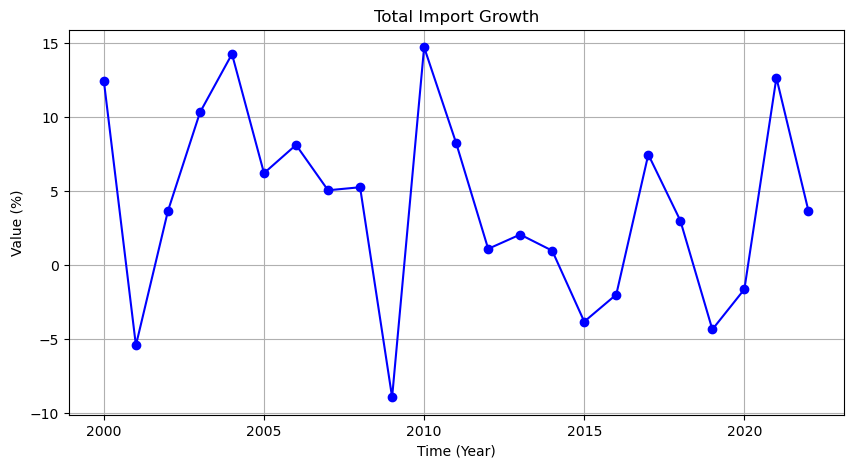

In [29]:
import matplotlib.pyplot as plt

# 그래프 설정
plt.figure(figsize=(10, 5))
plt.plot(filtered_df["Time"], filtered_df["Value"], marker="o", linestyle="-", color="b")

# 그래프 제목 및 레이블 설정
plt.title("Total Import Growth")
plt.xlabel("Time (Year)")
plt.ylabel("Value (%)")
plt.grid(True)
plt.show()

### 예 2: 한국 Tariff

In [30]:
import requests
import xml.etree.ElementTree as ET
import pandas as pd

# API 기본 URL
base_url = "https://wits.worldbank.org/API/V1/SDMX/V21/rest/data/"

# 요청 파라미터 설정
params = {
    "dataset": "df_wits_tradestats_tariff",  # df_wits_tradestats_trade, df_wits_tradestats_development 가능
    "freq": "A",
    "reporter": "KOR",
    "partner": "WLD",
    "product": "",
    "indicator": "",
    "detail": "Full"
}

# 연도 범위 설정
start_year = 2000
end_year = 2022

# 연도별 데이터 수집
all_data = []

for year in range(start_year, end_year + 1):
    # 요청 URL 생성
    url = (
        f"{base_url}{params['dataset']}/"
        f"{params['freq']}."
        f"{params['reporter']}."
        f"{params['partner']}."
        f"{params['product']}."
        f"{params['indicator']}/"
        f"?startperiod={year}"
        f"&endperiod={year}"
        f"&detail={params['detail']}"
    )

    # API 요청
    response = requests.get(url)
    if response.status_code != 200:
        print(f"Error fetching data for year {year}: {response.status_code}")
        continue

    # XML 파싱
    root = ET.fromstring(response.content)
    namespace = {"ns": "http://www.sdmx.org/resources/sdmxml/schemas/v2_1/data/generic"}

    # 데이터 추출
    for series in root.findall(".//ns:Series", namespace):
        series_key = {dim.get("id"): dim.get("value") for dim in series.findall(".//ns:SeriesKey/ns:Value", namespace)}
        for obs in series.findall(".//ns:Obs", namespace):
            obs_time = obs.find(".//ns:ObsDimension", namespace)
            obs_value = obs.find(".//ns:ObsValue", namespace)
            attributes = {attr.get("id"): attr.get("value") for attr in obs.findall(".//ns:Attributes/ns:Value", namespace)}
            if obs_time is not None and obs_value is not None:
                all_data.append({**series_key, "Time": obs_time.get("value"), "Value": obs_value.get("value"), **attributes})

# 데이터프레임 변환
df_tariff = pd.DataFrame(all_data)

# 결과 출력
df_tariff

Error fetching data for year 2019: 404


,FREQ,REPORTER,PARTNER,PRODUCTCODE,INDICATOR,Time,Value,DATASOURCE
0,A,KOR,WLD,01-05_Animal,AHS-AVE-TRFF-LN-SHR,2000,0.231850456455586,WITS-TRN
1,A,KOR,WLD,01-05_Animal,AHS-DTBL-MPRT,2000,2634922.208,WITS-TRN
2,A,KOR,WLD,01-05_Animal,AHS-DTBL-TRFF-LNS-SHR,2000,99.3044486306332,WITS-TRN
3,A,KOR,WLD,01-05_Animal,AHS-DTY-FR-MPRTs,2000,1340.749,WITS-TRN
4,A,KOR,WLD,01-05_Animal,AHS-DTY-FR-TRFF-LNS-SHR,2000,0.463700912911172,WITS-TRN
...,...,...,...,...,...,...,...,...
15329,A,KOR,WLD,UNCTAD-SoP4,MFN-SMPL-AVRG,2022,5.16601980079455,WITS-TRN
15330,A,KOR,WLD,UNCTAD-SoP4,MFN-SPCFC-DTY-MPRT,2022,0,WITS-TRN
15331,A,KOR,WLD,UNCTAD-SoP4,MFN-SPCFC-TRFF-LNS-SHR,2022,0,WITS-TRN
15332,A,KOR,WLD,UNCTAD-SoP4,MFN-TTL-TRFF-LNS,2022,2079,WITS-TRN


In [31]:
df_tariff["PRODUCTCODE"].unique()

array(['01-05_Animal', '06-15_Vegetable', '16-24_FoodProd',
       '25-26_Minerals', '27-27_Fuels', '28-38_Chemicals',
       '39-40_PlastiRub', '41-43_HidesSkin', '44-49_Wood',
       '50-63_TextCloth', '64-67_Footwear', '68-71_StoneGlas',
       '72-83_Metals', '84-85_MachElec', '86-89_Transport',
       '90-99_Miscellan', '999999', 'AgrRaw', 'Chemical', 'Food', 'Fuels',
       'manuf', 'OresMtls', 'Textiles', 'Total', 'Transp', 'UNCTAD-SoP1',
       'UNCTAD-SoP2', 'UNCTAD-SoP3', 'UNCTAD-SoP4'], dtype=object)

In [32]:
df_tariff["INDICATOR"].unique()

array(['AHS-AVE-TRFF-LN-SHR', 'AHS-DTBL-MPRT', 'AHS-DTBL-TRFF-LNS-SHR',
       'AHS-DTY-FR-MPRTs', 'AHS-DTY-FR-TRFF-LNS-SHR', 'AHS-MNMM-RATE',
       'AHS-MXMM-RT', 'AHS-SMPL-AVRG', 'AHS-SPCFC-DTY-MPRT',
       'AHS-SPCFC-TRFF-LNS-SHR', 'AHS-TTL-TRFF-LNS', 'AHS-WGHTD-AVRG',
       'MFN-AVE-TRFF-LNS-SHR', 'MFN-DTBL-MPRT', 'MFN-DTBL-TRFF-LNS-SHR',
       'MFN-DTY-FR-MPRTs', 'MFN-DTY-FR-TRFF-LNS-SHR', 'MFN-MNMN-RT',
       'MFN-MXMM-RT', 'MFN-SMPL-AVRG', 'MFN-SPCFC-DTY-MPRT',
       'MFN-SPCFC-TRFF-LNS-SHR', 'MFN-TTL-TRFF-LNS', 'MFN-WGHTD-AVRG',
       'TRF-NMBR-AGGRMNT'], dtype=object)

In [33]:
# 필터링 조건 설정
filtered_df = df_tariff[
    (df_tariff["PRODUCTCODE"] == "manuf") &
    (df_tariff["INDICATOR"] == "AHS-SMPL-AVRG")
]

# 결과 출력
filtered_df

,FREQ,REPORTER,PARTNER,PRODUCTCODE,INDICATOR,Time,Value,DATASOURCE
488,A,KOR,WLD,manuf,AHS-SMPL-AVRG,2000,8.04871188694919,WITS-TRN
1185,A,KOR,WLD,manuf,AHS-SMPL-AVRG,2001,8.0006037781408,WITS-TRN
1882,A,KOR,WLD,manuf,AHS-SMPL-AVRG,2002,7.84739834719468,WITS-TRN
2579,A,KOR,WLD,manuf,AHS-SMPL-AVRG,2003,7.65289036537507,WITS-TRN
3276,A,KOR,WLD,manuf,AHS-SMPL-AVRG,2004,7.28273166404962,WITS-TRN
3973,A,KOR,WLD,manuf,AHS-SMPL-AVRG,2005,7.2546772188867,WITS-TRN
4670,A,KOR,WLD,manuf,AHS-SMPL-AVRG,2006,7.3272158998234,WITS-TRN
5367,A,KOR,WLD,manuf,AHS-SMPL-AVRG,2007,6.60067248716548,WITS-TRN
6064,A,KOR,WLD,manuf,AHS-SMPL-AVRG,2008,7.43864307649827,WITS-TRN
6761,A,KOR,WLD,manuf,AHS-SMPL-AVRG,2009,7.39792922732952,WITS-TRN


In [34]:
filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22 entries, 488 to 15125
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   FREQ         22 non-null     object
 1   REPORTER     22 non-null     object
 2   PARTNER      22 non-null     object
 3   PRODUCTCODE  22 non-null     object
 4   INDICATOR    22 non-null     object
 5   Time         22 non-null     object
 6   Value        22 non-null     object
 7   DATASOURCE   22 non-null     object
dtypes: object(8)
memory usage: 1.5+ KB


In [35]:
filtered_df = filtered_df.copy()
filtered_df["Time"] = filtered_df["Time"].astype(int)
filtered_df["Value"] = filtered_df["Value"].astype(float)

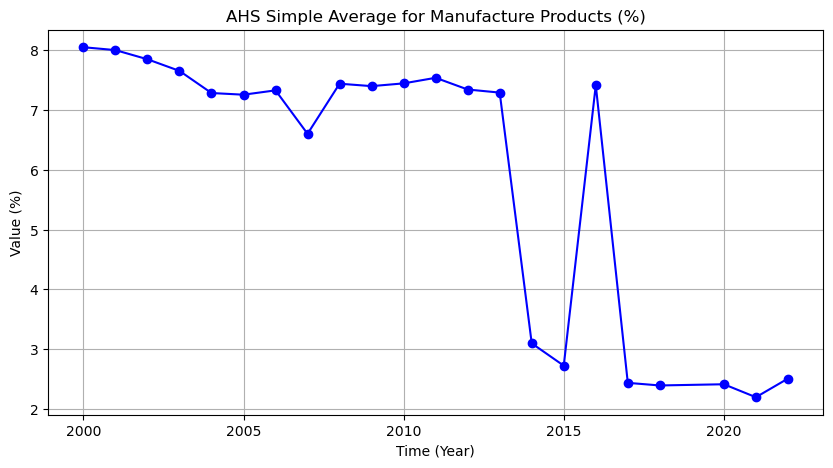

In [36]:
import matplotlib.pyplot as plt

# 그래프 설정
plt.figure(figsize=(10, 5))
plt.plot(filtered_df["Time"], filtered_df["Value"], marker="o", linestyle="-", color="b")

# 그래프 제목 및 레이블 설정
plt.title("AHS Simple Average for Manufacture Products (%)")
plt.xlabel("Time (Year)")
plt.ylabel("Value (%)")
plt.grid(True)
plt.show()